# Compare Auction Values

In [1]:
import pandas as pd
import seaborn as sns
pd.options.display.precision = 2
import matplotlib.pyplot as plt
import json
import sys

In [2]:
sys.path.append('../')

In [3]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [4]:
Calc_date = 'Feb25_2026'

In [5]:
Full_Merge_path = League_path+'/Full_Merge.csv'

In [6]:
TeamID = 240

In [7]:
Replacement_Level_Recalc_path = League_path+'/Recalc_Replacement_Level.csv'

In [8]:
Repl_Level_H_path = League_path+'/Latest_Hitter_Repl.csv'
Repl_Level_P_path = League_path+'/Latest_Pitcher_Repl.csv'

In [9]:
Target_Stats_path = League_path+'/Target_Stats_dict.json'

In [10]:
Additional_targets = {
    'G_mySGP':162.*12.,
    'G_FGAV': 162.*12.,
    'IP_mySGP':1500.,
    'IP_FGAV':1500.,
    'TOTAL_SGP_Val_mySGP':500., #terget value for full team
    'CAT_SGP_Val':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'Salary': 390. #assume 10 for in-season pickups
}

In [11]:
Val_per_SGP = {
    'Hitter': 6.349899134101533,
    'Pitcher': 4.757117079794198
}

In [12]:
Replacement_Level_Recalc_df = pd.read_csv(Replacement_Level_Recalc_path)

In [13]:
Replacement_Level_Orig_df = pd.concat([
    pd.read_csv(Repl_Level_H_path),
    pd.read_csv(Repl_Level_P_path)
])

In [14]:
with open(Target_Stats_path, 'r') as f:
    data = json.load(f)
    data.update(Additional_targets)
Target_Stats_df = pd.json_normalize(data)

In [15]:
Target_Stats_df.head()

,Target Pts,R,HR,OBP,SLG,K,HR9,ERA,WHIP,G_mySGP,G_FGAV,IP_mySGP,IP_FGAV,TOTAL_SGP_Val_mySGP,CAT_SGP_Val,Salary
0,10.44,1073.34,323.02,0.34,0.46,1634.48,0.99,3.38,1.13,1944.0,1944.0,1500.0,1500.0,500.0,200.0,390.0


In [16]:
Target_Stats_Hitter_df = Target_Stats_df[['Target Pts','R','HR','OBP','SLG','G_mySGP','G_FGAV','TOTAL_SGP_Val_mySGP','CAT_SGP_Val','Salary']]
Target_Stats_Hitter_df['Hitter Pitcher'] = 'Hitter'
Target_Stats_Pitcher_df = Target_Stats_df[['Target Pts','K','HR9','ERA','WHIP','IP_mySGP','IP_FGAV','TOTAL_SGP_Val_mySGP','CAT_SGP_Val','Salary']]
Target_Stats_Pitcher_df['Hitter Pitcher'] = 'Pitcher'
Target_Stats_Pitcher_df.rename(columns={'K':'SO'},inplace=True)
Target_Stats_df = pd.concat([
    Target_Stats_Hitter_df,
    Target_Stats_Pitcher_df
])

In [17]:
Target_Stats_df.head()

,Target Pts,R,HR,OBP,SLG,G_mySGP,G_FGAV,TOTAL_SGP_Val_mySGP,CAT_SGP_Val,Salary,Hitter Pitcher,SO,HR9,ERA,WHIP,IP_mySGP,IP_FGAV
0,10.44,1073.34,323.02,0.34,0.46,1944.0,1944.0,500.0,200.0,390.0,Hitter,NaN,NaN,NaN,NaN,NaN,NaN
0,10.44,NaN,NaN,NaN,NaN,NaN,NaN,500.0,200.0,390.0,Pitcher,1634.48,0.99,3.38,1.13,1500.0,1500.0


In [18]:
Player_id_cols = [
    'FG ID','Name','Team','Ottoneu ID','Ottoneu Positions'
]

In [19]:
Fantasy_Team_ID_cols = [
    'TeamID', 'Team Name',
]

In [20]:
Games_IP_Targets = {
    'C':162,
    '1B':162,
    '2B':162,
    '3B':162,
    'SS':162,
    'MI':162, 
    'OF':810, #total
    'Util':162, 
    'IP':1500 #total
}
Start_Spots = {
    'C':1, #technically 2 but 162 G limit
    '1B':1,
    '2B':1,
    'SS':1,
    'MI':1,
    '3B':1,
    'OF':5,
    'Util':1, #starting Hitters
    'SP':5,
    'RP':5
}

Total_Roster_Spots = {
    'C':2,
    '1B':2,
    '2B':3,
    'SS':3,
    '3B':2,
    'OF':9,
    'SP':9,
    'RP':6
}

In [21]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
League_budget = Team_budget*Num_teams
Hitter_budget = League_budget*Hitter_sal_split
Pitcher_budget = League_budget*(1.-Hitter_sal_split)
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [22]:
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'MI',
    'Util'
]
Pitching_Pos = [
    'SP',
    'RP'
]

All_Pos = Hitting_Pos + Pitching_Pos

In [23]:
Full_Merge_df = pd.read_csv(Full_Merge_path)
Full_Merge_df['FG ID'] = Full_Merge_df['FG ID'].astype(str)
Full_Merge_df['FG ID'] = Full_Merge_df['FG ID'].str.replace('.0','')
Full_Merge_df['Ottoneu ID'] = Full_Merge_df['Ottoneu ID'].astype(str)
Full_Merge_df['Ottoneu ID'] = Full_Merge_df['Ottoneu ID'].str.replace('.0','')

In [24]:
Full_Merge_sorted_df = Full_Merge_df.sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

In [25]:
def quick_plotting_fn(quick_plot):
    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(111)
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel('Player')
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    plt.tick_params(axis='y', which='major', labelsize=7)
    plt.show()

In [26]:
This_team_df = Full_Merge_sorted_df[Full_Merge_sorted_df['TeamID'] == TeamID]

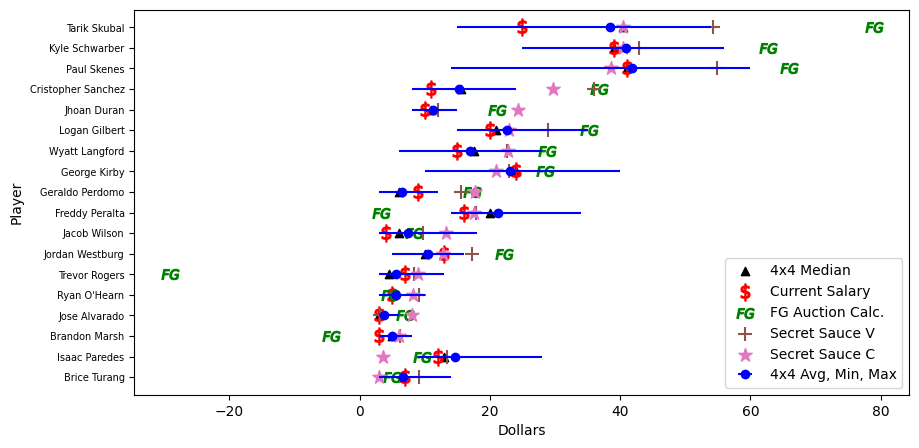

In [27]:
quick_plotting_fn(This_team_df)

In [28]:
Team_hitter_groupby = Full_Merge_sorted_df[~Full_Merge_sorted_df['Repl_Pos_mySGP'].isin(['SP', 'RP'])].groupby(['Team Name'])[[
    # 'Name',
    # 'Team',
    # 'Ottoneu Positions',
    # 'Repl_Pos_mySGP',
    'G_mySGP',
    'HR_mySGP',
    'R_mySGP',
    'OBP_mySGP',
    'SLG_mySGP',
    # 'IP_mySGP',
    'R_SGP_raw_mySGP',
    'HR_SGP_raw_mySGP',
    'OBP_SGP_raw_mySGP',
    'SLG_SGP_raw_mySGP',
    'R_SGP_norm_mySGP',
    'HR_SGP_norm_mySGP',
    'OBP_SGP_norm_mySGP',
    'SLG_SGP_norm_mySGP',
    # 'SO_mySGP',
    # 'HR9_mySGP',
    # 'ERA_mySGP',
    # 'WHIP_mySGP',
    # 'SO_SGP_Val_mySGP',
    # 'HR9_SGP_Val_mySGP',
    # 'ERA_SGP_Val_mySGP',
    # 'WHIP_SGP_Val_mySGP',
    'TOTAL_SGP_raw_mySGP',
    'TOTAL_SGP_mySGP',
    # 'TOTAL_SGP_Rank_mySGP',
    # 'TOTAL_SGP_Val_mySGP',
    # 'Dollars_FGAV',
    # 'Dollars_Vibbot',
    # 'Ottoneu_Avg',
    # 'Ottoneu_Med',
    # 'Ottoneu_Min',
    # 'Ottoneu_Max',
    # 'Ottoneu_L10',
    # 'Roster%',
    # 'TeamID',
    # 'Team Name',
    # 'Salary'
    ]].sum()



In [29]:
Team_hitter_groupby

,G_mySGP,HR_mySGP,R_mySGP,OBP_mySGP,SLG_mySGP,R_SGP_raw_mySGP,HR_SGP_raw_mySGP,OBP_SGP_raw_mySGP,SLG_SGP_raw_mySGP,R_SGP_norm_mySGP,HR_SGP_norm_mySGP,OBP_SGP_norm_mySGP,SLG_SGP_norm_mySGP,TOTAL_SGP_raw_mySGP,TOTAL_SGP_mySGP
Team Name,,,,,,,,,,,,,,,
Carlos Pérez's K-Dance,1746.19,245.14,897.87,4.16,5.39,35.51,21.30,-1.66,-1.47,7.39,7.84,0.84,2.50,53.68,18.57
Chili Dog MVP,1239.78,184.47,635.22,3.16,4.22,25.12,16.03,-1.54,-0.15,4.33,5.98,0.54,3.08,39.46,13.93
Hornswogglers,2174.45,321.62,1174.44,5.55,7.23,46.45,27.95,0.28,0.88,8.62,9.51,3.37,5.81,75.57,27.32
Jack Klugman's Second Best Lung,1918.65,300.09,1011.77,4.85,6.46,40.02,26.08,-0.77,1.25,6.75,9.04,2.28,5.18,66.57,23.25
Largely Indistinguishables,1238.08,176.46,677.73,3.04,3.86,26.81,15.33,2.42,0.29,6.99,6.07,3.98,3.11,44.85,20.15
Roar from 34,1343.77,229.83,754.29,3.32,4.50,29.83,19.97,1.79,3.11,8.15,9.22,3.78,6.07,54.71,27.22
Roberto Big Piece and the 69ers,1982.59,331.65,1100.14,4.65,6.30,43.51,28.82,2.05,3.53,12.72,13.34,4.82,7.48,77.91,38.36
Smoak and Mirrors,1392.54,195.32,744.63,3.36,4.34,29.45,16.97,2.21,0.76,7.42,6.22,3.92,3.78,49.39,21.34
St. CGT VI,1741.35,280.23,954.34,4.72,6.20,37.75,24.35,4.42,3.23,7.38,9.74,7.30,7.37,69.75,31.79


In [30]:
pd.DataFrame(((Team_hitter_groupby.loc['Largely Indistinguishables']/Team_hitter_groupby.sum())*100)[['G_mySGP',
    'HR_mySGP',
    'R_mySGP',
    'OBP_mySGP',
    'SLG_mySGP']]).T

,G_mySGP,HR_mySGP,R_mySGP,OBP_mySGP,SLG_mySGP
0,6.33,5.76,6.42,6.21,5.94


<Axes: >

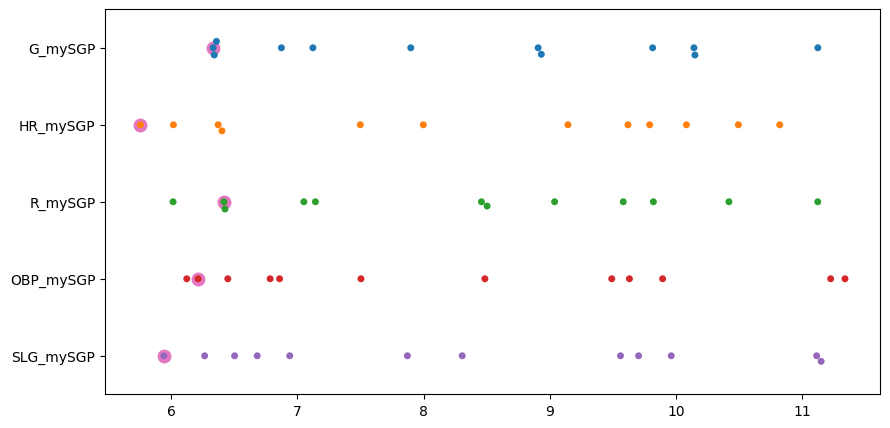

In [31]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.swarmplot(pd.DataFrame(((Team_hitter_groupby.loc['Largely Indistinguishables']/Team_hitter_groupby.sum())*100)[['G_mySGP',
    'HR_mySGP',
    'R_mySGP',
    'OBP_mySGP',
    'SLG_mySGP',
    ]]).T,orient='h',ax=ax1,color='tab:pink',size=10)
sns.swarmplot(((Team_hitter_groupby/Team_hitter_groupby.sum())*100)[['G_mySGP',
    'HR_mySGP',
    'R_mySGP',
    'OBP_mySGP',
    'SLG_mySGP']],orient='h',ax=ax1)

In [32]:
# fig = plt.figure(figsize=(10,5))
# ax1 = fig.add_subplot(111)
# sns.swarmplot(pd.DataFrame(((Team_hitter_groupby.loc['Largely Indistinguishables']/Team_hitter_groupby.sum())*100)[['R_SGP_raw_mySGP',
#     'HR_SGP_raw_mySGP',
#     'OBP_SGP_raw_mySGP',
#     'SLG_SGP_raw_mySGP',
#     'TOTAL_SGP_raw_mySGP']]).T,orient='h',ax=ax1,color='tab:pink',size=10)
# sns.swarmplot(((Team_hitter_groupby/Team_hitter_groupby.sum())*100)[['R_SGP_raw_mySGP',
#     'HR_SGP_raw_mySGP',
#     'OBP_SGP_raw_mySGP',
#     'SLG_SGP_raw_mySGP',
#     'TOTAL_SGP_raw_mySGP']],orient='h',ax=ax1)

<Axes: >

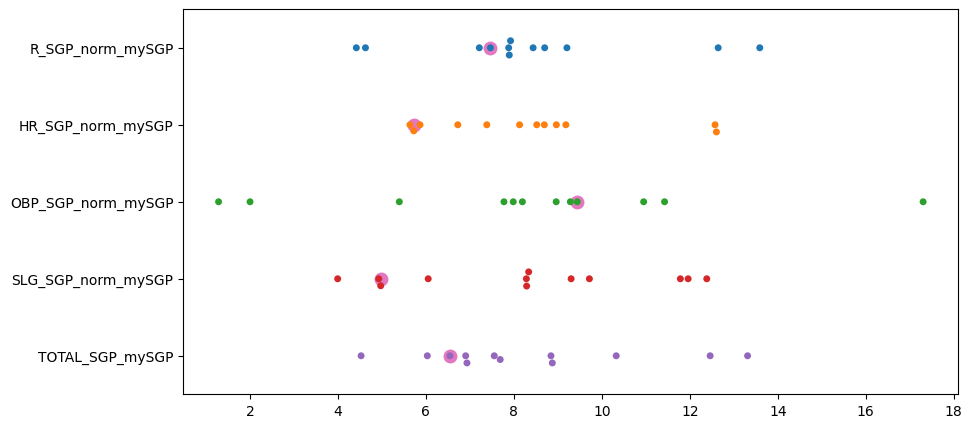

In [33]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.swarmplot(pd.DataFrame(((Team_hitter_groupby.loc['Largely Indistinguishables']/Team_hitter_groupby.sum())*100)[['R_SGP_norm_mySGP',
    'HR_SGP_norm_mySGP',
    'OBP_SGP_norm_mySGP',
    'SLG_SGP_norm_mySGP',
    'TOTAL_SGP_mySGP']]).T,orient='h',ax=ax1,color='tab:pink',size=10)
sns.swarmplot(((Team_hitter_groupby/Team_hitter_groupby.sum())*100)[['R_SGP_norm_mySGP',
    'HR_SGP_norm_mySGP',
    'OBP_SGP_norm_mySGP',
    'SLG_SGP_norm_mySGP',
    'TOTAL_SGP_mySGP']],orient='h',ax=ax1)

In [34]:
Team_pitcher_groupby = Full_Merge_sorted_df[Full_Merge_sorted_df['Repl_Pos_mySGP'].isin(['SP', 'RP'])].groupby(['Team Name'])[[
    # 'Name',
    # 'Team',
    # 'Ottoneu Positions',
    # 'Repl_Pos_mySGP',
    # 'G_mySGP',
    # 'HR_mySGP',
    # 'R_mySGP',
    # 'OBP_mySGP',
    # 'SLG_mySGP',
    'IP_mySGP',
    # 'R_SGP_raw_mySGP',
    # 'HR_SGP_raw_mySGP',
    # 'OBP_SGP_raw_mySGP',
    # 'SLG_SGP_raw_mySGP',
    # 'R_SGP_norm_mySGP',
    # 'HR_SGP_norm_mySGP',
    # 'OBP_SGP_norm_mySGP',
    # 'SLG_SGP_norm_mySGP',
    'SO_mySGP',
    'HR9_mySGP',
    'ERA_mySGP',
    'WHIP_mySGP',
    'SO_SGP_raw_mySGP',
    'HR9_SGP_raw_mySGP',
    'ERA_SGP_raw_mySGP',
    'WHIP_SGP_raw_mySGP',
    'SO_SGP_norm_mySGP',
    'HR9_SGP_norm_mySGP',
    'ERA_SGP_norm_mySGP',
    'WHIP_SGP_norm_mySGP',
    'TOTAL_SGP_raw_mySGP',
    'TOTAL_SGP_mySGP',
    # 'TOTAL_SGP_Rank_mySGP',
    # 'TOTAL_SGP_Val_mySGP',
    # 'Dollars_FGAV',
    # 'Dollars_Vibbot',
    # 'Ottoneu_Avg',
    # 'Ottoneu_Med',
    # 'Ottoneu_Min',
    # 'Ottoneu_Max',
    # 'Ottoneu_L10',
    # 'Roster%',
    # 'TeamID',
    # 'Team Name',
    # 'Salary'
    ]].sum()

<Axes: >

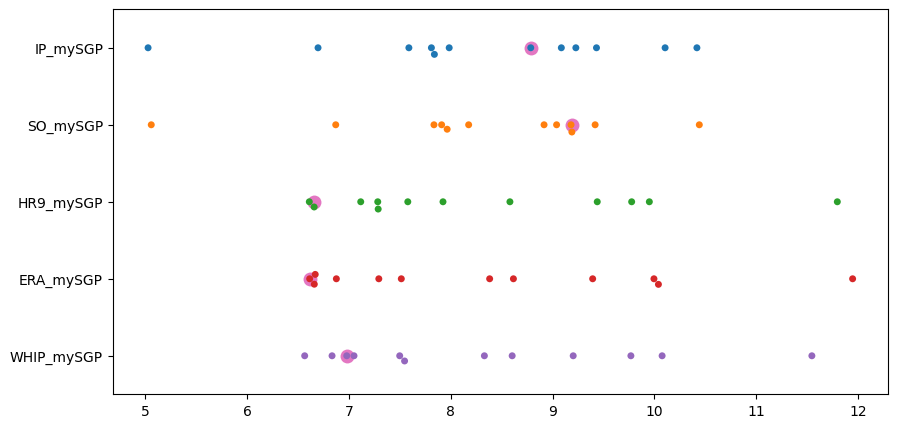

In [35]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.swarmplot(pd.DataFrame(((Team_pitcher_groupby.loc['Largely Indistinguishables']/Team_pitcher_groupby.sum())*100)[['IP_mySGP',
    'SO_mySGP',
    'HR9_mySGP',
    'ERA_mySGP',
    'WHIP_mySGP',
    ]]).T,orient='h',ax=ax1,color='tab:pink',size=10)
sns.swarmplot(((Team_pitcher_groupby/Team_pitcher_groupby.sum())*100)[['IP_mySGP',
    'SO_mySGP',
    'HR9_mySGP',
    'ERA_mySGP',
    'WHIP_mySGP']],orient='h',ax=ax1)

In [36]:
# fig = plt.figure(figsize=(10,5))
# ax1 = fig.add_subplot(111)
# sns.swarmplot(pd.DataFrame(((Team_pitcher_groupby.loc['Largely Indistinguishables']/Team_pitcher_groupby.sum())*100)[['SO_SGP_raw_mySGP',
#     'HR9_SGP_raw_mySGP',
#     'ERA_SGP_raw_mySGP',
#     'WHIP_SGP_raw_mySGP',
#     'TOTAL_SGP_raw_mySGP']]).T,orient='h',ax=ax1,color='tab:pink',size=10)
# sns.swarmplot(((Team_pitcher_groupby/Team_pitcher_groupby.sum())*100)[['SO_SGP_raw_mySGP',
#     'HR9_SGP_raw_mySGP',
#     'ERA_SGP_raw_mySGP',
#     'WHIP_SGP_raw_mySGP',
#     'TOTAL_SGP_raw_mySGP']],orient='h',ax=ax1)

<Axes: >

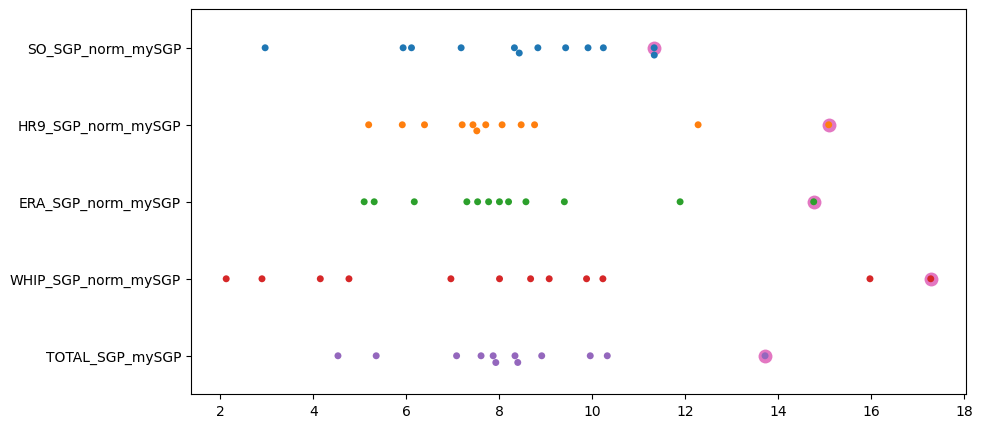

In [37]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.swarmplot(pd.DataFrame(((Team_pitcher_groupby.loc['Largely Indistinguishables']/Team_pitcher_groupby.sum())*100)[['SO_SGP_norm_mySGP',
    'HR9_SGP_norm_mySGP',
    'ERA_SGP_norm_mySGP',
    'WHIP_SGP_norm_mySGP',
    'TOTAL_SGP_mySGP']]).T,orient='h',ax=ax1,color='tab:pink',size=10)
sns.swarmplot(((Team_pitcher_groupby/Team_pitcher_groupby.sum())*100)[['SO_SGP_norm_mySGP',
    'HR9_SGP_norm_mySGP',
    'ERA_SGP_norm_mySGP',
    'WHIP_SGP_norm_mySGP',
    'TOTAL_SGP_mySGP']],orient='h',ax=ax1)

# Fully Replacement Roster

In [38]:
Target_Stats_df.head()

,Target Pts,R,HR,OBP,SLG,G_mySGP,G_FGAV,TOTAL_SGP_Val_mySGP,CAT_SGP_Val,Salary,Hitter Pitcher,SO,HR9,ERA,WHIP,IP_mySGP,IP_FGAV
0,10.44,1073.34,323.02,0.34,0.46,1944.0,1944.0,500.0,200.0,390.0,Hitter,NaN,NaN,NaN,NaN,NaN,NaN
0,10.44,NaN,NaN,NaN,NaN,NaN,NaN,500.0,200.0,390.0,Pitcher,1634.48,0.99,3.38,1.13,1500.0,1500.0


In [39]:
Replacement_Level_Recalc_df[['Ottoneu Positions','R_mySGP','HR_mySGP','OBP_mySGP','SLG_mySGP','SO_mySGP','HR9_mySGP','ERA_mySGP','WHIP_mySGP']]


,Ottoneu Positions,R_mySGP,HR_mySGP,OBP_mySGP,SLG_mySGP,SO_mySGP,HR9_mySGP,ERA_mySGP,WHIP_mySGP
0,C,49.39,12.67,0.31,0.40,NaN,NaN,NaN,NaN
1,1B,66.76,18.54,0.33,0.43,NaN,NaN,NaN,NaN
2,2B,63.02,12.64,0.32,0.39,NaN,NaN,NaN,NaN
3,SS,47.39,8.64,0.31,0.38,NaN,NaN,NaN,NaN
4,3B,63.92,17.69,0.32,0.42,NaN,NaN,NaN,NaN
5,MI,53.49,10.94,0.31,0.39,NaN,NaN,NaN,NaN
6,OF,54.73,12.01,0.31,0.40,NaN,NaN,NaN,NaN
7,Util,48.12,10.82,0.31,0.39,NaN,NaN,NaN,NaN
8,SP,NaN,NaN,NaN,NaN,87.82,1.14,4.01,1.27
9,RP,NaN,NaN,NaN,NaN,74.40,1.26,4.37,1.36


In [40]:
Replacement_Level_Orig_df[['Ottoneu Positions','G','R','HR','OBP','SLG','SO','HR9','ERA','WHIP','IP']]

,Ottoneu Positions,G,R,HR,OBP,SLG,SO,HR9,ERA,WHIP,IP
0,1B,137.87,67.19,20.21,0.32,0.42,NaN,NaN,NaN,NaN,NaN
1,2B,130.12,64.37,14.56,0.33,0.40,NaN,NaN,NaN,NaN,NaN
2,3B,122.27,60.02,14.90,0.32,0.40,NaN,NaN,NaN,NaN,NaN
3,C,102.44,44.56,11.82,0.31,0.38,NaN,NaN,NaN,NaN,NaN
4,OF,110.63,56.99,11.03,0.32,0.38,NaN,NaN,NaN,NaN,NaN
5,SS,88.75,44.30,9.21,0.31,0.38,NaN,NaN,NaN,NaN,NaN
6,Util,111.24,53.56,16.08,0.31,0.41,NaN,NaN,NaN,NaN,NaN
0,P,51.51,25.44,7.23,NaN,NaN,66.90,1.12,3.64,1.22,57.86
1,RP,51.04,30.83,8.37,NaN,NaN,71.16,1.11,3.76,1.24,67.60
2,SP,31.62,59.01,16.12,NaN,NaN,86.99,1.35,4.53,1.33,107.85


In [41]:
Replacement_Level_Recalc_df[['Ottoneu Positions','R_SGP_raw_mySGP','HR_SGP_raw_mySGP','OBP_SGP_raw_mySGP','SLG_SGP_raw_mySGP','SO_SGP_raw_mySGP','HR9_SGP_raw_mySGP','ERA_SGP_raw_mySGP','WHIP_SGP_raw_mySGP']]


,Ottoneu Positions,R_SGP_raw_mySGP,HR_SGP_raw_mySGP,OBP_SGP_raw_mySGP,SLG_SGP_raw_mySGP,SO_SGP_raw_mySGP,HR9_SGP_raw_mySGP,ERA_SGP_raw_mySGP,WHIP_SGP_raw_mySGP
0,C,1.95,1.10,-1.38e-01,-0.14,NaN,NaN,NaN,NaN
1,1B,2.64,1.61,-5.11e-03,0.02,NaN,NaN,NaN,NaN
2,2B,2.49,1.10,-8.23e-02,-0.18,NaN,NaN,NaN,NaN
3,SS,1.87,0.75,-2.21e-01,-0.31,NaN,NaN,NaN,NaN
4,3B,2.53,1.54,-6.64e-02,-0.08,NaN,NaN,NaN,NaN
5,MI,2.12,0.95,-1.74e-01,-0.24,NaN,NaN,NaN,NaN
6,OF,2.16,1.04,-1.56e-01,-0.16,NaN,NaN,NaN,NaN
7,Util,1.90,0.94,-1.94e-01,-0.21,NaN,NaN,NaN,NaN
8,SP,NaN,NaN,NaN,NaN,1.85,-0.19,-0.18,-0.22
9,RP,NaN,NaN,NaN,NaN,1.57,0.54,0.25,0.25


In [42]:
Replacement_Level_Orig_df[['Ottoneu Positions','R_SGP_raw','HR_SGP_raw','OBP_SGP_raw','SLG_SGP_raw','SO_SGP_raw','HR9_SGP_raw','ERA_SGP_raw','WHIP_SGP_raw','TOTAL_SGP_raw']]


,Ottoneu Positions,R_SGP_raw,HR_SGP_raw,OBP_SGP_raw,SLG_SGP_raw,SO_SGP_raw,HR9_SGP_raw,ERA_SGP_raw,WHIP_SGP_raw,TOTAL_SGP_raw
0,1B,2.66,1.76,-0.24,-0.03,NaN,NaN,NaN,NaN,4.15
1,2B,2.55,1.27,-0.02,-0.30,NaN,NaN,NaN,NaN,3.49
2,3B,2.37,1.29,-0.16,-0.21,NaN,NaN,NaN,NaN,3.30
3,C,1.76,1.03,-0.26,-0.32,NaN,NaN,NaN,NaN,2.21
4,OF,2.25,0.96,-0.20,-0.36,NaN,NaN,NaN,NaN,2.66
5,SS,1.75,0.80,-0.19,-0.29,NaN,NaN,NaN,NaN,2.07
6,Util,2.12,1.40,-0.21,-0.16,NaN,NaN,NaN,NaN,3.15
0,P,NaN,NaN,NaN,NaN,1.41,-0.21,0.23,0.25,1.68
1,RP,NaN,NaN,NaN,NaN,1.50,-0.19,0.08,0.11,1.49
2,SP,NaN,NaN,NaN,NaN,1.83,-0.41,-0.35,-0.23,0.83


In [43]:
Replacement_Level_Recalc_df[['Ottoneu Positions','R_SGP_norm_mySGP','HR_SGP_norm_mySGP','OBP_SGP_norm_mySGP','SLG_SGP_norm_mySGP','SO_SGP_norm_mySGP','HR9_SGP_norm_mySGP','ERA_SGP_norm_mySGP','WHIP_SGP_norm_mySGP']]

,Ottoneu Positions,R_SGP_norm_mySGP,HR_SGP_norm_mySGP,OBP_SGP_norm_mySGP,SLG_SGP_norm_mySGP,SO_SGP_norm_mySGP,HR9_SGP_norm_mySGP,ERA_SGP_norm_mySGP,WHIP_SGP_norm_mySGP
0,C,0.19,7.40e-02,0.12,1.84e-01,NaN,NaN,NaN,NaN
1,1B,0.24,2.30e-01,0.23,2.25e-01,NaN,NaN,NaN,NaN
2,2B,0.28,1.28e-01,0.11,1.46e-01,NaN,NaN,NaN,NaN
3,SS,0.12,-4.95e-02,-0.02,-5.97e-03,NaN,NaN,NaN,NaN
4,3B,0.40,4.08e-01,0.14,2.15e-01,NaN,NaN,NaN,NaN
5,MI,0.05,-9.86e-03,0.01,8.06e-02,NaN,NaN,NaN,NaN
6,OF,-0.06,9.17e-02,0.05,2.01e-01,NaN,NaN,NaN,NaN
7,Util,-0.24,-8.19e-02,0.01,1.10e-01,NaN,NaN,NaN,NaN
8,SP,NaN,NaN,NaN,NaN,0.23,0.22,0.18,0.01
9,RP,NaN,NaN,NaN,NaN,0.07,0.75,0.34,0.25


In [44]:
Replacement_Level_Recalc_df[['Ottoneu Positions','mR_FGAV','mHR_FGAV','mOBP_FGAV','mSLG_FGAV','mSO_FGAV','mERA_FGAV','mWHIP_FGAV']]

,Ottoneu Positions,mR_FGAV,mHR_FGAV,mOBP_FGAV,mSLG_FGAV,mSO_FGAV,mERA_FGAV,mWHIP_FGAV
0,C,-10.86,-9.15,-4.47e-01,-1.01,NaN,NaN,NaN
1,1B,-4.20,-3.94,1.63e-03,-0.10,NaN,NaN,NaN
2,2B,-6.12,-8.87,-9.84e-02,-1.34,NaN,NaN,NaN
3,SS,-12.87,-12.50,-1.08e+00,-3.56,NaN,NaN,NaN
4,3B,-4.58,-4.60,-9.02e-02,-0.29,NaN,NaN,NaN
5,MI,-9.91,-10.99,-5.63e-01,-2.05,NaN,NaN,NaN
6,OF,-9.14,-9.19,-2.59e-01,-0.58,NaN,NaN,NaN
7,Util,-11.63,-10.47,-2.82e-01,-0.62,NaN,NaN,NaN
8,SP,NaN,-6.37,NaN,NaN,0.05,-13.09,-11.72
9,RP,NaN,5.01,NaN,NaN,-2.43,-1.42,-2.36


In [45]:
Both_Replacement_Level_df = Replacement_Level_Recalc_df.merge(Replacement_Level_Orig_df,how='outer').set_index('Ottoneu Positions')

In [46]:
Both_Replacement_Level_df.columns

Index(['HR_SGP_Val_mySGP', 'HR_SGP_norm_mySGP', 'HR_SGP_raw_mySGP', 'HR_mySGP',
       'OBP_SGP_Val_mySGP', 'OBP_SGP_norm_mySGP', 'OBP_SGP_raw_mySGP',
       'OBP_mySGP', 'R_SGP_Val_mySGP', 'R_SGP_norm_mySGP', 'R_SGP_raw_mySGP',
       'R_mySGP', 'SLG_SGP_Val_mySGP', 'SLG_SGP_norm_mySGP',
       'SLG_SGP_raw_mySGP', 'SLG_mySGP', 'TOTAL_SGP_Val_mySGP', 'mHR_FGAV',
       'mOBP_FGAV', 'mR_FGAV', 'mSLG_FGAV', 'ERA_SGP_Val_mySGP',
       'ERA_SGP_norm_mySGP', 'ERA_SGP_raw_mySGP', 'ERA_mySGP',
       'HR9_SGP_Val_mySGP', 'HR9_SGP_norm_mySGP', 'HR9_SGP_raw_mySGP',
       'HR9_mySGP', 'SO_SGP_Val_mySGP', 'SO_SGP_norm_mySGP',
       'SO_SGP_raw_mySGP', 'SO_mySGP', 'WHIP_SGP_Val_mySGP',
       'WHIP_SGP_norm_mySGP', 'WHIP_SGP_raw_mySGP', 'WHIP_mySGP', 'mERA_FGAV',
       'mSO_FGAV', 'mWHIP_FGAV', '1B', '2B', '3B', 'AB', 'ADP', 'BB', 'G', 'H',
       'HBP', 'HR', 'PA', 'R', 'RBI', 'SF', 'WAR', 'R_SGP_raw', 'HR_SGP_raw',
       'OBP', 'OBP_SGP_raw', 'SLG', 'SLG_SGP_raw', 'TOTAL_SGP_raw', 'ER', 'G

In [47]:
Both_Replacement_Level_df[['R','R_mySGP','TOTAL_SGP_raw']]

,R,R_mySGP,TOTAL_SGP_raw
Ottoneu Positions,,,
1B,67.19,66.76,4.15
2B,64.37,63.02,3.49
3B,60.02,63.92,3.30
C,44.56,49.39,2.21
MI,NaN,53.49,NaN
OF,56.99,54.73,2.66
P,25.44,NaN,1.68
RP,30.83,NaN,1.49
SP,59.01,NaN,0.83


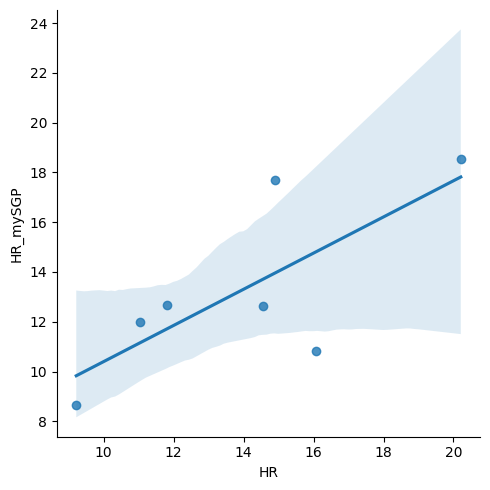

In [48]:
sns.lmplot(Both_Replacement_Level_df[['HR','HR_mySGP']],x='HR',y='HR_mySGP')

In [49]:
Both_Replacement_Level_df.loc['MI'].to_dict()

{'HR_SGP_Val_mySGP': -0.1711584859314435,
 'HR_SGP_norm_mySGP': -0.0098552101253499,
 'HR_SGP_raw_mySGP': 0.950676594377512,
 'HR_mySGP': 10.940769714285716,
 'OBP_SGP_Val_mySGP': 0.547538769316287,
 'OBP_SGP_norm_mySGP': 0.0102818944528842,
 'OBP_SGP_raw_mySGP': -0.1740899646115131,
 'OBP_mySGP': 0.3122632901867466,
 'R_SGP_Val_mySGP': 0.9912985626744678,
 'R_SGP_norm_mySGP': 0.0514222525861592,
 'R_SGP_raw_mySGP': 2.11557307812875,
 'R_mySGP': 53.48701333333333,
 'SLG_SGP_Val_mySGP': 2.7404707752318713,
 'SLG_SGP_norm_mySGP': 0.0805523252955358,
 'SLG_SGP_raw_mySGP': -0.2363981359751434,
 'SLG_mySGP': 0.3871543411484107,
 'TOTAL_SGP_Val_mySGP': -0.1970967857950321,
 'mHR_FGAV': -10.987533842267192,
 'mOBP_FGAV': -0.563367154404484,
 'mR_FGAV': -9.91106239679224,
 'mSLG_FGAV': -2.053950548748691,
 'ERA_SGP_Val_mySGP': nan,
 'ERA_SGP_norm_mySGP': nan,
 'ERA_SGP_raw_mySGP': nan,
 'ERA_mySGP': nan,
 'HR9_SGP_Val_mySGP': nan,
 'HR9_SGP_norm_mySGP': nan,
 'HR9_SGP_raw_mySGP': nan,
 'HR9_my

In [50]:
Games_IP_Targets

{'C': 162,
 '1B': 162,
 '2B': 162,
 '3B': 162,
 'SS': 162,
 'MI': 162,
 'OF': 810,
 'Util': 162,
 'IP': 1500}

In [51]:
Batting_value_columns = {
    'G':['TOTAL_SGP_Val_mySGP','TOTAL_SGP_raw'],
    'R':['R_mySGP','R_SGP_raw_mySGP','R_SGP_norm_mySGP','R_SGP_Val_mySGP','mR_FGAV'],
    'HR':['HR_mySGP','HR_SGP_raw_mySGP','HR_SGP_norm_mySGP','HR_SGP_Val_mySGP','mHR_FGAV'],
    'OBP':['OBP_mySGP','OBP_SGP_raw_mySGP','OBP_SGP_norm_mySGP','OBP_SGP_Val_mySGP','mOBP_FGAV'],
    'SLG':['SLG_mySGP','SLG_SGP_raw_mySGP','SLG_SGP_norm_mySGP','SLG_SGP_Val_mySGP','mSLG_FGAV']
}

Pitching_value_columns = {
    'IP':['TOTAL_SGP_Val_mySGP','TOTAL_SGP_raw'],
    'SO':['SO_mySGP','SO_SGP_raw_mySGP','SO_SGP_norm_mySGP','SO_SGP_Val_mySGP','mSO_FGAV'],
    'HR9':['HR9_mySGP','HR9_SGP_raw_mySGP','HR9_SGP_norm_mySGP','HR9_SGP_Val_mySGP','mHR_FGAV'],
    'ERA':['ERA_mySGP','ERA_SGP_raw_mySGP','ERA_SGP_norm_mySGP','ERA_SGP_Val_mySGP','mERA_FGAV'],
    'WHIP':['WHIP_mySGP','WHIP_SGP_raw_mySGP','WHIP_SGP_norm_mySGP','WHIP_SGP_Val_mySGP','mWHIP_FGAV']
}
count_cols_hitting = ['G'] + Batting_value_columns['G'] + \
             ['R'] + Batting_value_columns['R'] + \
             ['HR'] + Batting_value_columns['HR'] + \
             ['OBP_SGP_raw_mySGP','OBP_SGP_norm_mySGP','OBP_SGP_Val_mySGP','mOBP_FGAV'] + \
             ['SLG_SGP_raw_mySGP','SLG_SGP_norm_mySGP','SLG_SGP_Val_mySGP','mSLG_FGAV']
rate_cols_hitting = ['OBP','OBP_mySGP','SLG','SLG_mySGP']

count_cols_pitching = ['IP'] + Pitching_value_columns['IP'] + \
             ['SO'] + Pitching_value_columns['SO'] + \
             ['HR9_SGP_raw_mySGP','HR9_SGP_norm_mySGP','HR9_SGP_Val_mySGP','mHR_FGAV'] + \
             ['ERA_SGP_raw_mySGP','ERA_SGP_norm_mySGP','ERA_SGP_Val_mySGP','mERA_FGAV'] + \
             ['WHIP_SGP_raw_mySGP','WHIP_SGP_norm_mySGP','WHIP_SGP_Val_mySGP','mWHIP_FGAV']
rate_cols_pitching = ['HR9','HR9_mySGP','ERA','ERA_mySGP','WHIP','WHIP_mySGP']

Replacement_level_team_df = pd.DataFrame()
for pos,starters in Start_Spots.items():
    This_Pos_Replacement_Level = Both_Replacement_Level_df.loc[pos]
    if pos == 'MI':
        This_Pos_Replacement_Level = Both_Replacement_Level_df.loc['SS']
    This_Pos_Stat_Cats = Pitching_value_columns if pos in Pitching_Pos else Batting_value_columns
    count_cols = count_cols_pitching if pos in Pitching_Pos else count_cols_hitting
    rate_cols = rate_cols_pitching if pos in Pitching_Pos else rate_cols_hitting
    pos_G_IP_target = Games_IP_Targets['IP'] if pos in Pitching_Pos else Games_IP_Targets[pos]
    # print(pos_G_IP_target)
    # print((This_Pos_Replacement_Level['IP'] if pos in Pitching_Pos else This_Pos_Replacement_Level['G']))
    pos_count_norm = (pos_G_IP_target/(This_Pos_Replacement_Level['IP'] if pos in Pitching_Pos else This_Pos_Replacement_Level['G']))
    # print(pos, pos_G_IP_target)
    # print((This_Pos_Replacement_Level['G']))
    This_Pos_Replacement_Stats = {'Ottoneu Positions':pos,'Hitter Pitcher':('Pitcher' if pos in Pitching_Pos else 'Hitter')}
    for stat_cat, stat_cols in This_Pos_Stat_Cats.items():
        #print(stat_cat, stat_cols)
        this_stat_count_cols = list(set([stat_cat]+stat_cols) & set(count_cols))
        this_stat_rate_cols = list(set([stat_cat]+stat_cols) & set(rate_cols))
        This_Pos_Replacement_Starters = (This_Pos_Replacement_Level[this_stat_count_cols]*pos_count_norm).to_dict() | This_Pos_Replacement_Level[this_stat_rate_cols].apply(lambda value: [value]*starters).to_dict()
        # if pos == 'MI':
        #     display((This_Pos_Replacement_Level[this_stat_count_cols]*pos_count_norm).to_dict())
        #     display(This_Pos_Replacement_Level[this_stat_rate_cols].apply(lambda value: [value]*starters).to_dict())
        #     display(This_Pos_Replacement_Starters)
        #print(This_Pos_Replacement_Level[this_stat_rate_cols].apply(lambda value: [value]*starters).to_dict())
        This_Pos_Replacement_Stats = This_Pos_Replacement_Stats | This_Pos_Replacement_Starters
    Replacement_level_team_df = pd.concat([
        Replacement_level_team_df,
        pd.DataFrame([This_Pos_Replacement_Stats])
    ])
display(Replacement_level_team_df)
    

,Ottoneu Positions,Hitter Pitcher,G,TOTAL_SGP_Val_mySGP,TOTAL_SGP_raw,R_mySGP,R_SGP_norm_mySGP,R,R_SGP_Val_mySGP,mR_FGAV,...,ERA_SGP_norm_mySGP,ERA_SGP_raw_mySGP,ERA_mySGP,ERA,WHIP_SGP_raw_mySGP,mWHIP_FGAV,WHIP_SGP_norm_mySGP,WHIP_SGP_Val_mySGP,WHIP_mySGP,WHIP
0,C,Hitter,162.0,4.86,3.50,78.10,0.30,70.47,5.82,-17.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1B,Hitter,162.0,4.65,4.87,78.45,0.28,78.94,5.41,-4.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,2B,Hitter,162.0,3.14,4.35,78.46,0.35,80.14,6.80,-7.61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,SS,Hitter,162.0,0.21,3.77,86.51,0.22,80.86,4.31,-23.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,MI,Hitter,162.0,0.21,3.77,86.51,0.22,80.86,4.31,-23.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,3B,Hitter,162.0,6.96,4.37,84.69,0.53,79.52,10.30,-6.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,OF,Hitter,810.0,8.74,19.46,400.71,-0.44,417.30,-8.52,-66.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Util,Hitter,162.0,-3.02,4.58,70.08,-0.34,78.00,-6.60,-16.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,SP,Pitcher,NaN,28.61,11.59,NaN,NaN,NaN,NaN,NaN,...,2.45,-2.46,"[4.007876449941309, 4.007876449941309, 4.00787...","[4.528830910699042, 4.528830910699042, 4.52883...",-3.09,-162.99,0.17,6.44,"[1.265778111986574, 1.265778111986574, 1.26577...","[1.3256040069226882, 1.3256040069226882, 1.325..."
0,RP,Pitcher,NaN,115.12,33.16,NaN,NaN,NaN,NaN,NaN,...,7.48,5.60,"[4.370891035734283, 4.370891035734283, 4.37089...","[3.763819667545053, 3.763819667545053, 3.76381...",5.58,-52.38,5.46,202.05,"[1.3641081471348515, 1.3641081471348515, 1.364...","[1.2407807347105706, 1.2407807347105706, 1.240..."


In [52]:
Replacement_level_team_df.set_index(['Ottoneu Positions','Hitter Pitcher']).columns

Index(['G', 'TOTAL_SGP_Val_mySGP', 'TOTAL_SGP_raw', 'R_mySGP',
       'R_SGP_norm_mySGP', 'R', 'R_SGP_Val_mySGP', 'mR_FGAV',
       'R_SGP_raw_mySGP', 'mHR_FGAV', 'HR_SGP_raw_mySGP', 'HR',
       'HR_SGP_norm_mySGP', 'HR_SGP_Val_mySGP', 'HR_mySGP',
       'OBP_SGP_Val_mySGP', 'OBP_SGP_norm_mySGP', 'mOBP_FGAV',
       'OBP_SGP_raw_mySGP', 'OBP_mySGP', 'OBP', 'SLG_SGP_norm_mySGP',
       'mSLG_FGAV', 'SLG_SGP_raw_mySGP', 'SLG_SGP_Val_mySGP', 'SLG_mySGP',
       'SLG', 'IP', 'SO', 'SO_mySGP', 'mSO_FGAV', 'SO_SGP_Val_mySGP',
       'SO_SGP_norm_mySGP', 'SO_SGP_raw_mySGP', 'HR9_SGP_Val_mySGP',
       'HR9_SGP_norm_mySGP', 'HR9_SGP_raw_mySGP', 'HR9_mySGP', 'HR9',
       'mERA_FGAV', 'ERA_SGP_Val_mySGP', 'ERA_SGP_norm_mySGP',
       'ERA_SGP_raw_mySGP', 'ERA_mySGP', 'ERA', 'WHIP_SGP_raw_mySGP',
       'mWHIP_FGAV', 'WHIP_SGP_norm_mySGP', 'WHIP_SGP_Val_mySGP', 'WHIP_mySGP',
       'WHIP'],
      dtype='str')

In [53]:
Target_Stats_df.columns

Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher', 'SO',
       'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')

In [54]:
Target_Stats_df['TOTAL_SGP_raw'] = Target_Stats_df['Target Pts']*len(Scoring_Categories)
Target_Stats_df['R_mySGP_Team'] = Target_Stats_df['R']
Target_Stats_df['R_SGP_Val_mySGP_Team'] = Target_Stats_df['CAT_SGP_Val']
Target_Stats_df['R_SGP_raw_mySGP_Team'] = Target_Stats_df['Target Pts']
Target_Stats_df['R_SGP_norm_mySGP_Team'] = 1.
Target_Stats_df['mR_FGAV_Team'] = 1.
Target_Stats_df['HR_mySGP_Team'] = Target_Stats_df['HR']
Target_Stats_df['HR_SGP_Val_mySGP_Team'] = Target_Stats_df['CAT_SGP_Val']
Target_Stats_df['HR_SGP_raw_mySGP_Team'] = Target_Stats_df['Target Pts']
Target_Stats_df['HR_SGP_norm_mySGP_Team'] = 1.
Target_Stats_df['mHR_FGAV_Team'] = 1.
Target_Stats_df['OBP_Team'] = Target_Stats_df['OBP']
Target_Stats_df['OBP_SGP_Val_mySGP_Team'] = Target_Stats_df['CAT_SGP_Val']
Target_Stats_df['OBP_SGP_raw_mySGP_Team'] = Target_Stats_df['Target Pts']
Target_Stats_df['OBP_SGP_norm_mySGP_Team'] = 1.
Target_Stats_df['mOBP_FGAV_Team'] = 1.
Target_Stats_df['SLG_Team'] = Target_Stats_df['SLG']
Target_Stats_df['SLG_SGP_Val_mySGP_Team'] = Target_Stats_df['CAT_SGP_Val']
Target_Stats_df['SLG_SGP_raw_mySGP_Team'] = Target_Stats_df['Target Pts']
Target_Stats_df['SLG_SGP_norm_mySGP_Team'] = 1.
Target_Stats_df['mSLG_FGAV_Team'] = 1.

Target_Stats_df['SO_mySGP_Team'] = Target_Stats_df['SO']
Target_Stats_df['SO_SGP_Val_mySGP_Team'] = Target_Stats_df['CAT_SGP_Val']
Target_Stats_df['SO_SGP_raw_mySGP_Team'] = Target_Stats_df['Target Pts']
Target_Stats_df['SO_SGP_norm_mySGP_Team'] = 1.
Target_Stats_df['mSO_FGAV_Team'] = 1.
Target_Stats_df['HR9_Team'] = Target_Stats_df['HR9']
Target_Stats_df['HR9_SGP_Val_mySGP_Team'] = Target_Stats_df['CAT_SGP_Val']
Target_Stats_df['HR9_SGP_raw_mySGP_Team'] = Target_Stats_df['Target Pts']
Target_Stats_df['HR9_SGP_norm_mySGP_Team'] = 1.
Target_Stats_df['mHR_FGAV_Team'] = 1.
Target_Stats_df['ERA_Team'] = Target_Stats_df['ERA']
Target_Stats_df['ERA_SGP_Val_mySGP_Team'] = Target_Stats_df['CAT_SGP_Val']
Target_Stats_df['ERA_SGP_raw_mySGP_Team'] = Target_Stats_df['Target Pts']
Target_Stats_df['ERA_SGP_norm_mySGP_Team'] = 1.
Target_Stats_df['mERA_FGAV_Team'] = 1.
Target_Stats_df['WHIP_Team'] = Target_Stats_df['WHIP']
Target_Stats_df['WHIP_SGP_Val_mySGP_Team'] = Target_Stats_df['CAT_SGP_Val']
Target_Stats_df['WHIP_SGP_raw_mySGP_Team'] = Target_Stats_df['Target Pts']
Target_Stats_df['WHIP_SGP_norm_mySGP_Team'] = 1.
Target_Stats_df['mWHIP_FGAV_Team'] = 1.

In [55]:
# bugged_cols = rate_cols_hitting+rate_cols_pitching+[
#     'mR_FGAV', 'mHR_FGAV', 'mOBP_FGAV', 'mSLG_FGAV', 'mSO_FGAV', 'mHR_FGAV', 'mERA_FGAV', 'mWHIP_FGAV', 
#     'R_SGP_norm_mySGP','HR_SGP_norm_mySGP', 'OBP_SGP_norm_mySGP', 'SLG_SGP_norm_mySGP',
#     'SO_SGP_norm_mySGP','HR9_SGP_norm_mySGP', 'ERA_SGP_norm_mySGP', 'WHIP_SGP_norm_mySGP', 
#     'R_SGP_raw_mySGP','HR_SGP_raw_mySGP', 'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP',
#     'SO_SGP_raw_mySGP','HR9_SGP_raw_mySGP', 'ERA_SGP_raw_mySGP', 'WHIP_SGP_raw_mySGP'
# ]

In [56]:
# for Stat in list(Replacement_level_team_df[Replacement_level_team_df['Hitter Pitcher'] == 'Hitter'].dropna(axis=1).set_index(['Ottoneu Positions','Hitter Pitcher']).columns):
#     if Stat in bugged_cols:
#         continue
#     fig = plt.figure(figsize=(10,5))
#     ax1 = fig.add_subplot(111)
#     sns.scatterplot(Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == 'Hitter'],x='Hitter Pitcher',y=Stat,color='Red',label='Target',marker='D',ax=ax1)
#     sns.histplot(Replacement_level_team_df[Replacement_level_team_df['Hitter Pitcher'] == 'Hitter'],x='Hitter Pitcher',weights=Stat,hue='Ottoneu Positions', multiple='stack',ax=ax1)
#     plt.tight_layout()
#     plt.show()

In [57]:
This_team_df[['Name','Team','Ottoneu Positions','Repl_Pos_mySGP','TOTAL_SGP_mySGP']]

,Name,Team,Ottoneu Positions,Repl_Pos_mySGP,TOTAL_SGP_mySGP
644,Tarik Skubal,DET,SP,SP,8.50
219,Kyle Schwarber,PHI,OF,OF,6.36
1210,Paul Skenes,PIT,SP,SP,8.12
541,Cristopher Sanchez,PHI,SP,SP,6.23
547,Jhoan Duran,PHI,RP,RP,5.12
640,Logan Gilbert,SEA,SP,SP,4.83
1199,Wyatt Langford,TEX,OF,OF,3.59
793,George Kirby,SEA,SP,SP,4.41
674,Geraldo Perdomo,ARI,SS,SS,2.80
344,Freddy Peralta,NYM,SP,SP,3.71


In [58]:
Both_Replacement_Level_df[['R_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP']]

,R_SGP_raw_mySGP,TOTAL_SGP_Val_mySGP
Ottoneu Positions,,
1B,2.64,3.96
2B,2.49,2.52
3B,2.53,5.25
C,1.95,3.07
MI,2.12,-0.20
OF,2.16,1.19
P,NaN,2.03
RP,NaN,5.19
SP,NaN,2.06


In [59]:
This_team_df[['Name','Ottoneu Positions','Repl_Pos_mySGP','R_SGP_repl_mySGP','TOTAL_SGP_mySGP','TOTAL_SGP_Val_mySGP','TeamID','Team Name']]

,Name,Ottoneu Positions,Repl_Pos_mySGP,R_SGP_repl_mySGP,TOTAL_SGP_mySGP,TOTAL_SGP_Val_mySGP,TeamID,Team Name
644,Tarik Skubal,SP,SP,NaN,8.50,40.44,240.0,Largely Indistinguishables
219,Kyle Schwarber,OF,OF,2.25,6.36,40.40,240.0,Largely Indistinguishables
1210,Paul Skenes,SP,SP,NaN,8.12,38.63,240.0,Largely Indistinguishables
541,Cristopher Sanchez,SP,SP,NaN,6.23,29.65,240.0,Largely Indistinguishables
547,Jhoan Duran,RP,RP,NaN,5.12,24.36,240.0,Largely Indistinguishables
640,Logan Gilbert,SP,SP,NaN,4.83,22.97,240.0,Largely Indistinguishables
1199,Wyatt Langford,OF,OF,2.25,3.59,22.77,240.0,Largely Indistinguishables
793,George Kirby,SP,SP,NaN,4.41,20.99,240.0,Largely Indistinguishables
674,Geraldo Perdomo,SS,SS,1.75,2.80,17.79,240.0,Largely Indistinguishables
344,Freddy Peralta,SP,SP,NaN,3.71,17.64,240.0,Largely Indistinguishables


In [60]:
Both_Replacement_Level_df.loc['C'].keys()

Index(['HR_SGP_Val_mySGP', 'HR_SGP_norm_mySGP', 'HR_SGP_raw_mySGP', 'HR_mySGP',
       'OBP_SGP_Val_mySGP', 'OBP_SGP_norm_mySGP', 'OBP_SGP_raw_mySGP',
       'OBP_mySGP', 'R_SGP_Val_mySGP', 'R_SGP_norm_mySGP', 'R_SGP_raw_mySGP',
       'R_mySGP', 'SLG_SGP_Val_mySGP', 'SLG_SGP_norm_mySGP',
       'SLG_SGP_raw_mySGP', 'SLG_mySGP', 'TOTAL_SGP_Val_mySGP', 'mHR_FGAV',
       'mOBP_FGAV', 'mR_FGAV', 'mSLG_FGAV', 'ERA_SGP_Val_mySGP',
       'ERA_SGP_norm_mySGP', 'ERA_SGP_raw_mySGP', 'ERA_mySGP',
       'HR9_SGP_Val_mySGP', 'HR9_SGP_norm_mySGP', 'HR9_SGP_raw_mySGP',
       'HR9_mySGP', 'SO_SGP_Val_mySGP', 'SO_SGP_norm_mySGP',
       'SO_SGP_raw_mySGP', 'SO_mySGP', 'WHIP_SGP_Val_mySGP',
       'WHIP_SGP_norm_mySGP', 'WHIP_SGP_raw_mySGP', 'WHIP_mySGP', 'mERA_FGAV',
       'mSO_FGAV', 'mWHIP_FGAV', '1B', '2B', '3B', 'AB', 'ADP', 'BB', 'G', 'H',
       'HBP', 'HR', 'PA', 'R', 'RBI', 'SF', 'WAR', 'R_SGP_raw', 'HR_SGP_raw',
       'OBP', 'OBP_SGP_raw', 'SLG', 'SLG_SGP_raw', 'TOTAL_SGP_raw', 'ER', 'G

In [61]:
This_team_df['TeamID'].unique()[0]

np.float64(240.0)

In [62]:
list(Both_Replacement_Level_df.columns)

['HR_SGP_Val_mySGP',
 'HR_SGP_norm_mySGP',
 'HR_SGP_raw_mySGP',
 'HR_mySGP',
 'OBP_SGP_Val_mySGP',
 'OBP_SGP_norm_mySGP',
 'OBP_SGP_raw_mySGP',
 'OBP_mySGP',
 'R_SGP_Val_mySGP',
 'R_SGP_norm_mySGP',
 'R_SGP_raw_mySGP',
 'R_mySGP',
 'SLG_SGP_Val_mySGP',
 'SLG_SGP_norm_mySGP',
 'SLG_SGP_raw_mySGP',
 'SLG_mySGP',
 'TOTAL_SGP_Val_mySGP',
 'mHR_FGAV',
 'mOBP_FGAV',
 'mR_FGAV',
 'mSLG_FGAV',
 'ERA_SGP_Val_mySGP',
 'ERA_SGP_norm_mySGP',
 'ERA_SGP_raw_mySGP',
 'ERA_mySGP',
 'HR9_SGP_Val_mySGP',
 'HR9_SGP_norm_mySGP',
 'HR9_SGP_raw_mySGP',
 'HR9_mySGP',
 'SO_SGP_Val_mySGP',
 'SO_SGP_norm_mySGP',
 'SO_SGP_raw_mySGP',
 'SO_mySGP',
 'WHIP_SGP_Val_mySGP',
 'WHIP_SGP_norm_mySGP',
 'WHIP_SGP_raw_mySGP',
 'WHIP_mySGP',
 'mERA_FGAV',
 'mSO_FGAV',
 'mWHIP_FGAV',
 '1B',
 '2B',
 '3B',
 'AB',
 'ADP',
 'BB',
 'G',
 'H',
 'HBP',
 'HR',
 'PA',
 'R',
 'RBI',
 'SF',
 'WAR',
 'R_SGP_raw',
 'HR_SGP_raw',
 'OBP',
 'OBP_SGP_raw',
 'SLG',
 'SLG_SGP_raw',
 'TOTAL_SGP_raw',
 'ER',
 'GS',
 'HLD',
 'IP',
 'L',
 'QS',
 '

In [63]:
All_teams_replacement_level = pd.DataFrame()
for teamID in Full_Merge_sorted_df['TeamID'].dropna().unique():
    One_team_plus_Replacement_level_df = pd.DataFrame()
    This_team_df = Full_Merge_sorted_df[Full_Merge_sorted_df['TeamID'] == teamID]
    print(This_team_df['Team Name'].unique()[0])
    This_team_df['Repl_Pos_mySGP'] = This_team_df['Repl_Pos_mySGP'].fillna('MiLB')
    This_team_df['Repl_Pos_mySGP'] = This_team_df['Repl_Pos_mySGP'].replace({'Util/SP':'Util'})
    #display(This_team_df[['Name','Team','Ottoneu Positions','Repl_Pos_mySGP','TOTAL_SGP_mySGP','TOTAL_SGP_Val_mySGP']])
    team_pos_override = Total_Roster_Spots.copy()
    for pos,spots in team_pos_override.items(): #MI after 2B and SS
        This_Pos_Replacement_Level = Both_Replacement_Level_df.loc[pos]
        This_Pos_one_team = This_team_df[This_team_df['Repl_Pos_mySGP'].apply(lambda x : pos in x.split('/'))]
        #  if pos == 'MI':
        #     This_Pos_Replacement_Level = Both_Replacement_Level_df.loc['SS']
        #     This_team_2B = This_team_df[This_team_df['Repl_Pos_mySGP'].apply(lambda x : '2B' in x.split('/'))]
        #     This_team_SS = This_team_df[This_team_df['Repl_Pos_mySGP'].apply(lambda x : 'SS' in x.split('/'))]
        #     This_Pos_one_team = pd.concat([This_team_2B,This_team_SS]).sort_values('TOTAL_SGP_mySGP',ascending=False)
        if pos == 'Util':
            This_Pos_one_team = This_team_df[~This_team_df['Repl_Pos_mySGP'].isin(['SP','RP','SP/RP'])]
        
        if One_team_plus_Replacement_level_df.shape[0] != 0:
            This_Pos_one_team = This_Pos_one_team[(~This_Pos_one_team['Ottoneu ID'].isin(list(One_team_plus_Replacement_level_df['Ottoneu ID'].unique())))]
        This_Pos_one_team['Roster_Spot'] = pos
        One_team_plus_Replacement_level_df = pd.concat([
            One_team_plus_Replacement_level_df,
            This_Pos_one_team.sort_values('TOTAL_SGP_mySGP',ascending=False)#.head(Total_Roster_Spots.get(pos))
        ])
        Num_Repl_this_pos = spots - One_team_plus_Replacement_level_df[One_team_plus_Replacement_level_df['Roster_Spot'] == pos].shape[0]
        if Num_Repl_this_pos < 0:
            print('*** ', pos,'Over allocated ***')

        # print(pos)
        # print('Roster Spots:', spots)
        # print('Num Replacement:', Num_Repl_this_pos)
        # print('Num Starters:', Start_Spots[pos])
        while Num_Repl_this_pos > 0:
            Num_Repl_this_pos-=1
            Replacement_Player = {
                'Name':f'Replacement {pos} {Num_Repl_this_pos+1}',
                'Ottoneu Positions':pos,
                'Repl_Pos_mySGP':pos,
                'Roster_Spot':pos,
                'G_mySGP':This_Pos_Replacement_Level['G'],
                'PA_mySGP':This_Pos_Replacement_Level['PA'],
                'AB_mySGP':This_Pos_Replacement_Level['AB'],
                'H_mySGP':This_Pos_Replacement_Level['H'],
                '1B_mySGP':This_Pos_Replacement_Level['1B'],
                '2B_mySGP':This_Pos_Replacement_Level['2B'],
                '3B_mySGP':This_Pos_Replacement_Level['3B'],
                'HR_mySGP':This_Pos_Replacement_Level['HR_mySGP'],
                'R_mySGP':This_Pos_Replacement_Level['R_mySGP'],
                'RBI_mySGP':This_Pos_Replacement_Level['RBI'],
                'BB_mySGP':This_Pos_Replacement_Level['BB'],
                'HBP_mySGP':This_Pos_Replacement_Level['HBP'],
                'SF_mySGP':This_Pos_Replacement_Level['SF'],
                'WAR_mySGP':This_Pos_Replacement_Level['WAR'],
                'ADP_mySGP':This_Pos_Replacement_Level['ADP'],
                'POS_mySGP':pos,
                #'Ottoneu ID':,
                'OBP_mySGP':This_Pos_Replacement_Level['OBP_mySGP'],
                #'TB_mySGP':This_Pos_Replacement_Level['TB'],
                'SLG_mySGP':This_Pos_Replacement_Level['SLG_mySGP'],
                #'Pos Place_mySGP':This_Pos_Replacement_Level['Pos Place_mySGP'],
                'R_SGP_raw_mySGP':This_Pos_Replacement_Level['R_SGP_raw_mySGP'],
                'HR_SGP_raw_mySGP':This_Pos_Replacement_Level['HR_SGP_raw_mySGP'],
                'OBP_SGP_raw_mySGP':This_Pos_Replacement_Level['OBP_SGP_raw_mySGP'],
                'SLG_SGP_raw_mySGP':This_Pos_Replacement_Level['SLG_SGP_raw_mySGP'],
                'TOTAL_SGP_raw_mySGP':This_Pos_Replacement_Level['TOTAL_SGP_raw'],
                'R_SGP_repl_mySGP':This_Pos_Replacement_Level['R_SGP_raw_mySGP'],
                'Repl_Pos_mySGP':pos,
                'R_SGP_norm_mySGP':This_Pos_Replacement_Level['R_SGP_norm_mySGP'],
                'HR_SGP_repl_mySGP':This_Pos_Replacement_Level['HR_SGP_raw_mySGP'],
                'HR_SGP_norm_mySGP':This_Pos_Replacement_Level['HR_SGP_norm_mySGP'],
                'OBP_SGP_repl_mySGP':This_Pos_Replacement_Level['OBP_SGP_raw_mySGP'],
                'OBP_SGP_norm_mySGP':This_Pos_Replacement_Level['OBP_SGP_norm_mySGP'],
                'SLG_SGP_repl_mySGP':This_Pos_Replacement_Level['SLG_SGP_raw_mySGP'],
                'SLG_SGP_norm_mySGP':This_Pos_Replacement_Level['SLG_SGP_norm_mySGP'],
                #'TOTAL_SGP_mySGP':This_Pos_Replacement_Level['TOTAL_SGP_raw'],
                #'TOTAL_SGP_Rank_mySGP':This_Pos_Replacement_Level['TOTAL_SGP_Rank_mySGP'],
                'TOTAL_SGP_Val_mySGP':This_Pos_Replacement_Level['TOTAL_SGP_Val_mySGP'],
                'R_SGP_Val_mySGP':This_Pos_Replacement_Level['R_SGP_Val_mySGP'],
                'HR_SGP_Val_mySGP':This_Pos_Replacement_Level['HR_SGP_Val_mySGP'],
                'OBP_SGP_Val_mySGP':This_Pos_Replacement_Level['OBP_SGP_Val_mySGP'],
                'SLG_SGP_Val_mySGP':This_Pos_Replacement_Level['SLG_SGP_Val_mySGP'],
                'W_mySGP':This_Pos_Replacement_Level['W'],
                'L_mySGP':This_Pos_Replacement_Level['L'],
                'QS_mySGP':This_Pos_Replacement_Level['QS'],
                'GS_mySGP':This_Pos_Replacement_Level['GS'],
                'SV_mySGP':This_Pos_Replacement_Level['SV'],
                'HLD_mySGP':This_Pos_Replacement_Level['HLD'],
                'IP_mySGP':This_Pos_Replacement_Level['IP'],
                'TBF_mySGP':This_Pos_Replacement_Level['TBF'],
                'ER_mySGP':This_Pos_Replacement_Level['ER'],
                'SO_mySGP':This_Pos_Replacement_Level['SO_mySGP'],
                'HR9_mySGP':This_Pos_Replacement_Level['HR9_mySGP'],
                'ERA_mySGP':This_Pos_Replacement_Level['ERA_mySGP'],
                'WHIP_mySGP':This_Pos_Replacement_Level['WHIP_mySGP'],
                'SO_SGP_raw_mySGP':This_Pos_Replacement_Level['SO_SGP_raw_mySGP'],
                'HR9_SGP_raw_mySGP':This_Pos_Replacement_Level['HR9_SGP_raw_mySGP'],
                'ERA_SGP_raw_mySGP':This_Pos_Replacement_Level['ERA_SGP_raw_mySGP'],
                'WHIP_SGP_raw_mySGP':This_Pos_Replacement_Level['WHIP_SGP_raw_mySGP'],
                'SO_SGP_repl_mySGP':This_Pos_Replacement_Level['SO_SGP_raw_mySGP'],
                'SO_SGP_norm_mySGP':This_Pos_Replacement_Level['SO_SGP_norm_mySGP'],
                'HR9_SGP_repl_mySGP':This_Pos_Replacement_Level['HR9_SGP_raw_mySGP'],
                'HR9_SGP_norm_mySGP':This_Pos_Replacement_Level['HR9_SGP_norm_mySGP'],
                'ERA_SGP_repl_mySGP':This_Pos_Replacement_Level['ERA_SGP_raw_mySGP'],
                'ERA_SGP_norm_mySGP':This_Pos_Replacement_Level['ERA_SGP_norm_mySGP'],
                'WHIP_SGP_repl_mySGP':This_Pos_Replacement_Level['WHIP_SGP_raw_mySGP'],
                'WHIP_SGP_norm_mySGP':This_Pos_Replacement_Level['WHIP_SGP_norm_mySGP'],
                'SO_SGP_Val_mySGP':This_Pos_Replacement_Level['SO_SGP_Val_mySGP'],
                'HR9_SGP_Val_mySGP':This_Pos_Replacement_Level['HR9_SGP_Val_mySGP'],
                'ERA_SGP_Val_mySGP':This_Pos_Replacement_Level['ERA_SGP_Val_mySGP'],
                'WHIP_SGP_Val_mySGP':This_Pos_Replacement_Level['WHIP_SGP_Val_mySGP'],
                'POS_FGAV':pos,
                'ADP_FGAV':This_Pos_Replacement_Level['ADP'],
                'PA_FGAV':This_Pos_Replacement_Level['PA'],
                'mR_FGAV':This_Pos_Replacement_Level['mR_FGAV'],
                'mHR_FGAV':This_Pos_Replacement_Level['mHR_FGAV'],
                'mOBP_FGAV':This_Pos_Replacement_Level['mOBP_FGAV'],
                'mSLG_FGAV':This_Pos_Replacement_Level['mSLG_FGAV'],
                #'PTS_FGAV':This_Pos_Replacement_Level['PTS_FGAV'],
                #'aPOS_FGAV':This_Pos_Replacement_Level['aPOS_FGAV'],
                #'Dollars_FGAV':This_Pos_Replacement_Level['Dollars_FGAV'],
                #'NameASCII_FGAV':This_Pos_Replacement_Level['NameASCII_FGAV'],
                #'MLBAMID_FGAV':This_Pos_Replacement_Level['MLBAMID_FGAV'],
                'IP_FGAV':This_Pos_Replacement_Level['IP'],
                'mERA_FGAV':This_Pos_Replacement_Level['mERA_FGAV'],
                'mWHIP_FGAV':This_Pos_Replacement_Level['mWHIP_FGAV'],
                'mSO_FGAV':This_Pos_Replacement_Level['mSO_FGAV'],
                #'Dollars_Vibbot':This_Pos_Replacement_Level['Dollars_Vibbot'],
                # 'Ottoneu_Avg':This_Pos_Replacement_Level['Ottoneu_Avg'],
                # 'Ottoneu_Med':This_Pos_Replacement_Level['Ottoneu_Med'],
                # 'Ottoneu_Min':This_Pos_Replacement_Level['Ottoneu_Min'],
                # 'Ottoneu_Max':This_Pos_Replacement_Level['Ottoneu_Max'],
                # 'Ottoneu_L10':This_Pos_Replacement_Level['Ottoneu_L10'],
                # 'Roster%':This_Pos_Replacement_Level['Roster%'],
                'TeamID':This_team_df['TeamID'].unique()[0],
                'Team Name':This_team_df['Team Name'].unique()[0],
                'Salary':1.
            }
            One_team_plus_Replacement_level_df = pd.concat([
                One_team_plus_Replacement_level_df,
                pd.DataFrame([Replacement_Player])
            ])

    One_team_plus_Replacement_level_df = pd.concat([
        One_team_plus_Replacement_level_df,
        This_team_df[This_team_df['Repl_Pos_mySGP'] == 'MiLB']
    ])
    One_team_plus_Replacement_level_df.reset_index(drop=True,inplace=True)
    #display(One_team_plus_Replacement_level_df[['Name','Team','Ottoneu Positions','Repl_Pos_mySGP','Roster_Spot','TOTAL_SGP_raw_mySGP','TOTAL_SGP_mySGP','TOTAL_SGP_Val_mySGP']])
    All_teams_replacement_level = pd.concat(
        [
            All_teams_replacement_level,
            One_team_plus_Replacement_level_df
        ]
    )

The Rime of Jamie Moyer
St. CGT VI
Yoshi Teddy Bear
Largely Indistinguishables
Roberto Big Piece and the 69ers
Hornswogglers
***  SP Over allocated ***
🦫 Beavers in Scoring Position!
***  SP Over allocated ***
Roar from 34
Smoak and Mirrors
Jack Klugman's Second Best Lung
***  1B Over allocated ***
Carlos Pérez's K-Dance
Chili Dog MVP
***  SP Over allocated ***


# Manual Review of each team

In [64]:
Beavers_df = All_teams_replacement_level[All_teams_replacement_level['Team Name'] == '🦫 Beavers in Scoring Position!']

Beavers_df = Beavers_df[~Beavers_df['Name'].isin([
    'Replacement 2B 3',
    'Replacement 2B 2',
    #'Replacement 2B 1',
    'Replacement RP 6',
    'Replacement RP 5',
    'Replacement RP 4',
    'Replacement RP 3',
    'Replacement RP 2',

])].reset_index(drop=True)

# display(Beavers_df[['Name','Team','Ottoneu Positions','Repl_Pos_mySGP','Roster_Spot','TOTAL_SGP_raw_mySGP','TOTAL_SGP_mySGP','TOTAL_SGP_Val_mySGP']])

In [65]:
All_teams_replacement_level = pd.concat(
    [
        All_teams_replacement_level[(All_teams_replacement_level['Team Name'] != '🦫 Beavers in Scoring Position!')],
        Beavers_df
    ]).reset_index(drop=True)

#Beavers_df = All_teams_replacement_level[All_teams_replacement_level['Team Name'] == '🦫 Beavers in Scoring Position!']

In [66]:
Second_Best_Lung_df = All_teams_replacement_level[(All_teams_replacement_level['Team Name'] == "Jack Klugman's Second Best Lung")]

In [67]:
Second_Best_Lung_df = Second_Best_Lung_df[
    ~Second_Best_Lung_df['Name'].isin([
'Replacement 2B 3',
'Replacement RP 3',
#'Replacement OF 3'
    ])].reset_index(drop=True)

In [68]:
All_teams_replacement_level = pd.concat(
    [
        All_teams_replacement_level[(All_teams_replacement_level['Team Name'] != "Jack Klugman's Second Best Lung")],
        Second_Best_Lung_df
    ]).reset_index(drop=True)

In [69]:
#Second_Best_Lung_df = All_teams_replacement_level[(All_teams_replacement_level['Team Name'] == "Jack Klugman's Second Best Lung")].reset_index()

In [70]:
Chili_Dog_MVP_df = All_teams_replacement_level[All_teams_replacement_level['Team Name'] == 'Chili Dog MVP'].reset_index(drop=True)

In [71]:
Chili_Dog_MVP_df = Chili_Dog_MVP_df[
    ~Chili_Dog_MVP_df['Name'].isin([
'Replacement 2B 3',
'Replacement 2B 2',
'Replacement RP 5',
'Replacement RP 4',
#'Replacement OF 3'
    ])].reset_index(drop=True)

In [72]:
All_teams_replacement_level = pd.concat(
    [
        All_teams_replacement_level[(All_teams_replacement_level['Team Name'] != "Chili Dog MVP")],
        Chili_Dog_MVP_df
    ]).reset_index(drop=True)

In [73]:
# Chili_Dog_MVP_df = All_teams_replacement_level[All_teams_replacement_level['Team Name'] == 'Chili Dog MVP'].reset_index(drop=True)

In [74]:
# display(Chili_Dog_MVP_df[['Name','Team','Ottoneu Positions','Repl_Pos_mySGP','Roster_Spot','TOTAL_SGP_raw_mySGP','TOTAL_SGP_mySGP','TOTAL_SGP_Val_mySGP']])

In [75]:
#list(All_teams_replacement_level.columns)

In [76]:
All_teams_replacement_level['Roster_Spot_Rank'] = All_teams_replacement_level.groupby(['TeamID','Roster_Spot'])['TOTAL_SGP_raw_mySGP'].rank('first',ascending=False)

In [77]:
display(All_teams_replacement_level[All_teams_replacement_level['TeamID'] == 55][['Name','Team Name','Ottoneu Positions','Roster_Spot','Roster_Spot_Rank','G_mySGP','IP_mySGP']])

,Name,Team Name,Ottoneu Positions,Roster_Spot,Roster_Spot_Rank,G_mySGP,IP_mySGP
376,Ben Rice,Jack Klugman's Second Best Lung,C/1B,C,1.0,132.48,NaN
377,Replacement C 1,Jack Klugman's Second Best Lung,C,C,2.0,102.44,NaN
378,Vinnie Pasquantino,Jack Klugman's Second Best Lung,1B,1B,1.0,147.51,NaN
379,Spencer Torkelson,Jack Klugman's Second Best Lung,1B,1B,2.0,149.27,NaN
380,Josh Naylor,Jack Klugman's Second Best Lung,1B,1B,3.0,143.61,NaN
381,Replacement 2B 2,Jack Klugman's Second Best Lung,2B,2B,1.0,130.12,NaN
382,Replacement 2B 1,Jack Klugman's Second Best Lung,2B,2B,2.0,130.12,NaN
383,Bo Bichette,Jack Klugman's Second Best Lung,SS,SS,1.0,147.18,NaN
384,CJ Abrams,Jack Klugman's Second Best Lung,SS,SS,2.0,144.41,NaN
385,Maikel Garcia,Jack Klugman's Second Best Lung,2B/SS/3B/OF,SS,3.0,152.73,NaN


In [78]:
def group_and_limit_sum(df, limits_dict):
    """
    Groups a DataFrame by columns 'TeamID' and 'Roster_Spot', then in order of rank on 'Roster_Spot_Rank', 
    sums column 'G_mySGP' until a limit (from limits_dict, keyed by 'Roster_Spot') is reached, 
    adding a column 'scale_factor' for the final rank to match the remainder.

    Args:
        df (pd.DataFrame): The input DataFrame with columns 'TeamID', 'Roster_Spot', 'Roster_Spot_Rank', 'G_mySGP'.
        limits_dict (dict): A dictionary where keys match unique values in column 'Roster_Spot' 
                            and values are the sum limits for column 'G_mySGP'.

    Returns:
        pd.DataFrame: The modified DataFrame with added 'cumulative_sum' and 
                      'scale_factor' columns. The 'scale_factor' is 1.0 for 
                      ranks fully included and <= 1.0 for the final, partially 
                      included rank.
    """
    
    # 1. Sort the DataFrame by columns 'TeamID', 'Roster_Spot', and 'Roster_Spot_Rank' (for ranking)
    # This ensures correct ordering within each group before applying cumulative logic.
    df_sorted = df.sort_values(by=['TeamID', 'Roster_Spot', 'Roster_Spot_Rank']).reset_index(drop=True)

    # 2. Define a custom function to apply to each group
    def apply_limit_and_scale(group):
        b_key = group.name[1]
        limit = limits_dict.get(b_key, group['G_mySGP'].sum()) # Default to total sum if key missing
        
        # Calculate cumulative sum
        cum_sum = group['G_mySGP'].cumsum()
        #print(b_key, cum_sum)
        
        # Determine which rows exceed the limit
        exceeded_limit = cum_sum > limit
        
        # Identify the first row that exceeds the limit
        first_exceed_index = exceeded_limit.idxmax() if exceeded_limit.any() else None
        
        # Calculate scale factors
        scale_factors = pd.Series(1.0, index=group.index)
        if first_exceed_index is not None:
            # For rows after the first exceeded, set factor to 0
            scale_factors.loc[first_exceed_index+1:] = 0.0
            
            # For the first exceeded row, calculate the proportional scale factor
            previous_sum = cum_sum.loc[:first_exceed_index-1].iloc[-1] if first_exceed_index != group.index[0] else 0 #.sum()
            remaining = limit - previous_sum
            scale_factors.loc[first_exceed_index] = remaining / group.loc[first_exceed_index, 'G_mySGP']
            
        group['G_mySGP_scale_factor'] = scale_factors
        group['capped_G_mySGP'] = group['G_mySGP'] * group['G_mySGP_scale_factor']
        group['cumulative_capped_G_mySGP_sum'] = group['capped_G_mySGP'].cumsum()
        
        return group

    # 3. Apply the custom function to each group
    # We use groupby on 'TeamID' and 'Roster_Spot' and then apply the custom function
    df_result = df_sorted.groupby(['TeamID', 'Roster_Spot']).apply(apply_limit_and_scale)

    return df_result.sort_index() # Revert to original index order if needed



In [79]:
Hitters_G_played_df = group_and_limit_sum(All_teams_replacement_level[~All_teams_replacement_level['Roster_Spot'].isin(['SP','RP'])], Games_IP_Targets).reset_index()

In [80]:
Hitters_G_played_df = Hitters_G_played_df.drop('level_2',axis=1)

In [81]:
MI_candidates = Hitters_G_played_df[(Hitters_G_played_df['Roster_Spot'].isin(['2B','SS'])) & (Hitters_G_played_df['G_mySGP_scale_factor'] < 1)].reset_index(drop=True)

In [82]:
MI_candidates = MI_candidates.join(MI_candidates.groupby('TeamID')['TOTAL_SGP_raw_mySGP'].rank('first',ascending=False).reset_index().rename(columns={'TOTAL_SGP_raw_mySGP':'MI_Rank'})).reset_index(drop=True)#[['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','G_mySGP','G_mySGP_scale_factor', 'capped_G_mySGP', 'cumulative_capped_G_mySGP_sum']]

In [83]:
MI_candidates = MI_candidates.drop('index',axis=1)

In [84]:
MI_candidates['G_MI_avail'] = MI_candidates['G_mySGP'] - MI_candidates['capped_G_mySGP']

In [85]:
#display(MI_candidates[MI_candidates['TeamID'] == 55][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','G_mySGP','G_mySGP_scale_factor', 'capped_G_mySGP', 'G_MI_avail']])#,'MI_scale_factor','capped_MI_G_mySGP']])

In [86]:
def apply_limit_and_scale_MI(group):
    # Sort by rank
    group = group.sort_values('MI_Rank').reset_index()
    limit = Games_IP_Targets['MI']
    
    # Calculate cumulative sum
    group['cum_sum'] = group['G_MI_avail'].cumsum()
    
    # Identify row where limit is exceeded
    group['over_limit'] = group['cum_sum'] > limit
    
    # Initialize scale factor
    group['MI_scale_factor'] = 1.0
    
    # Find first row over limit
    over_limit_idx = group[group['over_limit']].index

    #print(group)
    
    if not over_limit_idx.empty:
        idx = over_limit_idx[0]
        # Calculate factor for the boundary row
        prev_sum = group.loc[:idx-1, 'G_MI_avail'].sum() if idx > group.index[0] else 0
        remaining = limit - prev_sum
        group.loc[idx, 'MI_scale_factor'] = max(0, remaining / group.loc[idx, 'G_MI_avail'])
        
        # Zero out rows after the limit
        group.loc[idx+1:, 'MI_scale_factor'] = 0.0
        #group.loc[idx+1:, 'G_MI_avail'] = 0.0
        # Cap the breaking row
        #group.loc[idx, 'G_MI_avail'] = max(0, remaining)

    
    group['capped_MI_G_mySGP'] = group['G_MI_avail'] * group['MI_scale_factor']
        
    return group.drop(columns=['cum_sum', 'over_limit'])

# Apply to groups
MI_candidates = MI_candidates.groupby('TeamID').apply(apply_limit_and_scale_MI).reset_index()
#print(MI_candidates)

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/305480106.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group['capped_MI_G_mySGP'] = group['G_MI_avail'] * group['MI_scale_factor']
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/305480106.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group['capped_MI_G_mySGP'] = group['G_MI_avail'] * group['MI_scale_factor']
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/305480106.py:34: PerformanceWarning: DataFrame is highly frag

In [87]:
#display(MI_candidates[MI_candidates['TeamID'] == 55][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','G_mySGP','G_mySGP_scale_factor', 'capped_G_mySGP', 'G_MI_avail','MI_scale_factor','capped_MI_G_mySGP']])

In [88]:
MI_candidates = MI_candidates.drop(['level_1','index'],axis=1)

In [89]:
Hitters_G_played_df = Hitters_G_played_df.merge(MI_candidates,how='left')#[['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','G_mySGP','G_mySGP_scale_factor', 'capped_G_mySGP', 'G_MI_avail','MI_scale_factor','capped_MI_G_mySGP']]

In [90]:
#display(Hitters_G_played_df[Hitters_G_played_df['TeamID'] == 55][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','G_mySGP','G_mySGP_scale_factor', 'capped_G_mySGP', 'G_MI_avail','MI_scale_factor','capped_MI_G_mySGP']])

In [91]:
UT_candidates = Hitters_G_played_df[(~Hitters_G_played_df['Roster_Spot'].isin(['SP','RP'])) & (Hitters_G_played_df['G_mySGP_scale_factor'] < 1) & ((Hitters_G_played_df['MI_scale_factor'].isna()) | (Hitters_G_played_df['MI_scale_factor'] < 1))].reset_index(drop=True)

In [92]:
UT_candidates = UT_candidates.join(UT_candidates.groupby('TeamID')['TOTAL_SGP_raw_mySGP'].rank('first',ascending=False).reset_index(name='Util_Rank'))

In [93]:
UT_candidates['G_Util_avail'] = UT_candidates['G_mySGP'] - UT_candidates['capped_G_mySGP'] - UT_candidates['capped_MI_G_mySGP'].fillna(0)

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/3639066650.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  UT_candidates['G_Util_avail'] = UT_candidates['G_mySGP'] - UT_candidates['capped_G_mySGP'] - UT_candidates['capped_MI_G_mySGP'].fillna(0)


In [94]:
#display(UT_candidates[UT_candidates['TeamID'] == 240][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','G_mySGP','G_mySGP_scale_factor', 'capped_G_mySGP', 'G_MI_avail','MI_scale_factor','capped_MI_G_mySGP','Util_Rank','G_Util_avail']])

In [95]:
def apply_limit_and_scale_Util(group):
    # Sort by rank
    group = group.sort_values('Util_Rank').reset_index()
    limit = Games_IP_Targets['Util']
    
    # Calculate cumulative sum
    group['cum_sum'] = group['G_Util_avail'].cumsum()
    
    # Identify row where limit is exceeded
    group['over_limit'] = group['cum_sum'] > limit
    
    # Initialize scale factor
    group['Util_scale_factor'] = 1.0
    
    # Find first row over limit
    over_limit_idx = group[group['over_limit']].index

    #print(group)
    
    if not over_limit_idx.empty:
        idx = over_limit_idx[0]
        # Calculate factor for the boundary row
        prev_sum = group.loc[:idx-1, 'G_Util_avail'].sum() if idx > group.index[0] else 0
        remaining = limit - prev_sum
        group.loc[idx, 'Util_scale_factor'] = max(0, remaining / group.loc[idx, 'G_Util_avail'])
        
        # Zero out rows after the limit
        group.loc[idx+1:, 'Util_scale_factor'] = 0.0
        #group.loc[idx+1:, 'G_MI_avail'] = 0.0
        # Cap the breaking row
        #group.loc[idx, 'G_MI_avail'] = max(0, remaining)

    
    group['capped_Util_G_mySGP'] = group['G_Util_avail'] * group['Util_scale_factor']
        
    return group.drop(columns=['cum_sum', 'over_limit'])

# Apply to groups
UT_candidates = UT_candidates.groupby('TeamID').apply(apply_limit_and_scale_Util).reset_index()
#print(MI_candidates)

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/2164387031.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group = group.sort_values('Util_Rank').reset_index()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/2164387031.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group['cum_sum'] = group['G_Util_avail'].cumsum()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/2164387031.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [96]:
#display(UT_candidates[UT_candidates['TeamID'] == 240][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','G_mySGP','G_mySGP_scale_factor', 'capped_G_mySGP', 'G_MI_avail','MI_scale_factor','capped_MI_G_mySGP','Util_Rank','G_Util_avail','Util_scale_factor','capped_Util_G_mySGP']])

In [97]:
UT_candidates = UT_candidates.drop(['level_1','level_0','index'],axis=1)

In [98]:
Hitters_G_played_df = Hitters_G_played_df.merge(UT_candidates,how='left')

In [99]:
display(Hitters_G_played_df[Hitters_G_played_df['TeamID'] == 240][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','G_mySGP','G_mySGP_scale_factor', 'capped_G_mySGP', 'G_MI_avail','MI_scale_factor','capped_MI_G_mySGP','Util_Rank','G_Util_avail','Util_scale_factor','capped_Util_G_mySGP']])

,Name,TeamID,Team Name,Ottoneu Positions,TOTAL_SGP_raw_mySGP,TOTAL_SGP_Val_mySGP,Roster_Spot,Roster_Spot_Rank,MI_Rank,G_mySGP,G_mySGP_scale_factor,capped_G_mySGP,G_MI_avail,MI_scale_factor,capped_MI_G_mySGP,Util_Rank,G_Util_avail,Util_scale_factor,capped_Util_G_mySGP
145,Replacement 1B 2,240.0,Largely Indistinguishables,1B,4.15,3.96,1B,1.0,NaN,137.87,1.00,137.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146,Replacement 1B 1,240.0,Largely Indistinguishables,1B,4.15,3.96,1B,2.0,NaN,137.87,0.18,24.13,NaN,NaN,NaN,1.0,113.74,1.00,113.74
147,Brice Turang,240.0,Largely Indistinguishables,2B,3.96,2.96,2B,1.0,NaN,150.79,1.00,150.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,Replacement 2B 2,240.0,Largely Indistinguishables,2B,3.49,2.52,2B,2.0,2.0,130.12,0.09,11.21,118.92,0.24,28.08,3.0,90.84,0.00,0.00
149,Replacement 2B 1,240.0,Largely Indistinguishables,2B,3.49,2.52,2B,3.0,3.0,130.12,0.00,0.00,130.12,0.00,0.00,4.0,130.12,0.00,0.00
150,Jordan Westburg,240.0,Largely Indistinguishables,2B/3B,5.20,12.85,3B,1.0,NaN,140.33,1.00,140.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,Isaac Paredes,240.0,Largely Indistinguishables,3B,3.87,3.63,3B,2.0,NaN,107.63,0.20,21.67,NaN,NaN,NaN,2.0,85.95,0.56,48.26
152,Replacement C 2,240.0,Largely Indistinguishables,C,2.21,3.07,C,1.0,NaN,102.44,1.00,102.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,Replacement C 1,240.0,Largely Indistinguishables,C,2.21,3.07,C,2.0,NaN,102.44,0.58,59.56,NaN,NaN,NaN,8.0,42.88,0.00,0.00
154,Kyle Schwarber,240.0,Largely Indistinguishables,OF,9.02,40.40,OF,1.0,NaN,156.75,1.00,156.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
Hitters_G_played_df['G_mySGP_Team'] = Hitters_G_played_df['capped_G_mySGP'] + Hitters_G_played_df['capped_MI_G_mySGP'].fillna(0) + Hitters_G_played_df['capped_Util_G_mySGP'].fillna(0)

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/2661876424.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Hitters_G_played_df['G_mySGP_Team'] = Hitters_G_played_df['capped_G_mySGP'] + Hitters_G_played_df['capped_MI_G_mySGP'].fillna(0) + Hitters_G_played_df['capped_Util_G_mySGP'].fillna(0)


In [101]:
Hitters_G_played_df['Hitter_Team_G_mySGP_SF'] = Hitters_G_played_df['G_mySGP_Team']/Hitters_G_played_df['G_mySGP']

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/463898959.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Hitters_G_played_df['Hitter_Team_G_mySGP_SF'] = Hitters_G_played_df['G_mySGP_Team']/Hitters_G_played_df['G_mySGP']


In [102]:
display(Hitters_G_played_df[Hitters_G_played_df['TeamID'] == 240][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','MI_Rank','Util_Rank','G_mySGP','G_mySGP_Team','Hitter_Team_G_mySGP_SF']])

,Name,TeamID,Team Name,Ottoneu Positions,TOTAL_SGP_raw_mySGP,TOTAL_SGP_Val_mySGP,Roster_Spot,Roster_Spot_Rank,MI_Rank,Util_Rank,G_mySGP,G_mySGP_Team,Hitter_Team_G_mySGP_SF
145,Replacement 1B 2,240.0,Largely Indistinguishables,1B,4.15,3.96,1B,1.0,NaN,NaN,137.87,137.87,1.00
146,Replacement 1B 1,240.0,Largely Indistinguishables,1B,4.15,3.96,1B,2.0,NaN,1.0,137.87,137.87,1.00
147,Brice Turang,240.0,Largely Indistinguishables,2B,3.96,2.96,2B,1.0,NaN,NaN,150.79,150.79,1.00
148,Replacement 2B 2,240.0,Largely Indistinguishables,2B,3.49,2.52,2B,2.0,2.0,3.0,130.12,39.28,0.30
149,Replacement 2B 1,240.0,Largely Indistinguishables,2B,3.49,2.52,2B,3.0,3.0,4.0,130.12,0.00,0.00
150,Jordan Westburg,240.0,Largely Indistinguishables,2B/3B,5.20,12.85,3B,1.0,NaN,NaN,140.33,140.33,1.00
151,Isaac Paredes,240.0,Largely Indistinguishables,3B,3.87,3.63,3B,2.0,NaN,2.0,107.63,69.93,0.65
152,Replacement C 2,240.0,Largely Indistinguishables,C,2.21,3.07,C,1.0,NaN,NaN,102.44,102.44,1.00
153,Replacement C 1,240.0,Largely Indistinguishables,C,2.21,3.07,C,2.0,NaN,8.0,102.44,59.56,0.58
154,Kyle Schwarber,240.0,Largely Indistinguishables,OF,9.02,40.40,OF,1.0,NaN,NaN,156.75,156.75,1.00


In [103]:
def group_and_limit_sum_IP(df, limits_dict):
    """
    Groups a DataFrame by columns 'TeamID', then in order of rank on 'IP_Rank', 
    sums column 'IP_mySGP' until a limit (from limits_dict, keyed by 'Roster_Spot') is reached, 
    adding a column 'scale_factor' for the final rank to match the remainder.

    Args:
        df (pd.DataFrame): The input DataFrame with columns 'TeamID', 'IP_Rank', 'IP_mySGP'.
        limits_dict (dict): A dictionary whith limits 
                            and values are the sum limits for column 'IP_mySGP'.

    Returns:
        pd.DataFrame: The modified DataFrame with added 'cumulative_sum' and 
                      'scale_factor' columns. The 'scale_factor' is 1.0 for 
                      ranks fully included and <= 1.0 for the final, partially 
                      included rank.
    """
    
    # 1. Sort the DataFrame by columns 'TeamID', 'Roster_Spot', and 'Roster_Spot_Rank' (for ranking)
    # This ensures correct ordering within each group before applying cumulative logic.
    df_sorted = df.sort_values(by=['TeamID', 'IP_Rank']).reset_index(drop=True)

    # 2. Define a custom function to apply to each group
    def apply_limit_and_scale(group):
        b_key = 'IP'
        limit = limits_dict.get(b_key, group['IP_mySGP'].sum()) # Default to total sum if key missing
        
        # Calculate cumulative sum
        cum_sum = group['IP_mySGP'].cumsum()
        #print(b_key, cum_sum)
        
        # Determine which rows exceed the limit
        exceeded_limit = cum_sum > limit
        
        # Identify the first row that exceeds the limit
        first_exceed_index = exceeded_limit.idxmax() if exceeded_limit.any() else None
        
        # Calculate scale factors
        scale_factors = pd.Series(1.0, index=group.index)
        if first_exceed_index is not None:
            # For rows after the first exceeded, set factor to 0
            scale_factors.loc[first_exceed_index+1:] = 0.0
            
            # For the first exceeded row, calculate the proportional scale factor
            previous_sum = cum_sum.loc[:first_exceed_index-1].iloc[-1] if first_exceed_index != group.index[0] else 0 #.sum()
            remaining = limit - previous_sum
            scale_factors.loc[first_exceed_index] = remaining / group.loc[first_exceed_index, 'IP_mySGP']
            
        group['IP_mySGP_scale_factor'] = scale_factors
        group['capped_IP_mySGP'] = group['IP_mySGP'] * group['IP_mySGP_scale_factor']
        group['cumulative_capped_IP_mySGP_sum'] = group['capped_IP_mySGP'].cumsum()
        
        return group

    # 3. Apply the custom function to each group
    # We use groupby on 'TeamID' and then apply the custom function
    df_result = df_sorted.groupby(['TeamID']).apply(apply_limit_and_scale)

    return df_result.sort_index() # Revert to original index order if needed

In [104]:
Pitcher_candidates = All_teams_replacement_level[All_teams_replacement_level['Roster_Spot'].isin(['SP','RP'])].reset_index(drop=True).join(All_teams_replacement_level[All_teams_replacement_level['Roster_Spot'].isin(['SP','RP'])].groupby('TeamID')['TOTAL_SGP_raw_mySGP'].rank('first',ascending=False).reset_index(name='IP_Rank'))

In [105]:
Pitcher_candidates = Pitcher_candidates.drop('index',axis=1)

In [106]:
#display(Pitcher_candidates[Pitcher_candidates['TeamID'] == 240][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','IP_Rank','IP_mySGP']])

In [107]:
Pitchers_IP_played_df = group_and_limit_sum_IP(Pitcher_candidates, Games_IP_Targets).reset_index()

In [108]:
Pitchers_IP_played_df = Pitchers_IP_played_df.drop('level_1',axis=1)

In [109]:
Pitchers_IP_played_df['Pitcher_Team_IP_mySGP_SF'] = Pitchers_IP_played_df['capped_IP_mySGP']/Pitchers_IP_played_df['IP_mySGP']

In [110]:
display(Pitchers_IP_played_df[Pitchers_IP_played_df['TeamID'] == 240][['Name','TeamID', 'Team Name','Ottoneu Positions','TOTAL_SGP_raw_mySGP','TOTAL_SGP_Val_mySGP','Roster_Spot','Roster_Spot_Rank','IP_Rank','IP_mySGP','IP_mySGP_scale_factor', 'capped_IP_mySGP', 'cumulative_capped_IP_mySGP_sum','Pitcher_Team_IP_mySGP_SF']])

,Name,TeamID,Team Name,Ottoneu Positions,TOTAL_SGP_raw_mySGP,TOTAL_SGP_Val_mySGP,Roster_Spot,Roster_Spot_Rank,IP_Rank,IP_mySGP,IP_mySGP_scale_factor,capped_IP_mySGP,cumulative_capped_IP_mySGP_sum,Pitcher_Team_IP_mySGP_SF
107,Tarik Skubal,240.0,Largely Indistinguishables,SP,9.33,40.44,SP,1.0,1.0,198.90,1.00,198.90,198.90,1.00
108,Paul Skenes,240.0,Largely Indistinguishables,SP,8.95,38.63,SP,2.0,2.0,193.45,1.00,193.45,392.34,1.00
109,Cristopher Sanchez,240.0,Largely Indistinguishables,SP,7.07,29.65,SP,3.0,3.0,196.69,1.00,196.69,589.03,1.00
110,Jhoan Duran,240.0,Largely Indistinguishables,RP,6.61,24.36,RP,1.0,4.0,69.05,1.00,69.05,658.09,1.00
111,Logan Gilbert,240.0,Largely Indistinguishables,SP,5.66,22.97,SP,4.0,5.0,166.64,1.00,166.64,824.72,1.00
112,George Kirby,240.0,Largely Indistinguishables,SP,5.25,20.99,SP,5.0,6.0,172.69,1.00,172.69,997.41,1.00
113,Freddy Peralta,240.0,Largely Indistinguishables,SP,4.54,17.64,SP,6.0,7.0,167.77,1.00,167.77,1165.19,1.00
114,Jose Alvarado,240.0,Largely Indistinguishables,RP,3.19,8.05,RP,2.0,8.0,61.38,1.00,61.38,1226.57,1.00
115,Trevor Rogers,240.0,Largely Indistinguishables,SP,2.73,9.00,SP,7.0,9.0,169.81,1.00,169.81,1396.38,1.00
116,Replacement RP 4,240.0,Largely Indistinguishables,RP,1.49,5.19,RP,3.0,10.0,67.60,1.00,67.60,1463.98,1.00


In [111]:
hitting_cols_to_scale = [
 'G_mySGP',
 'PA_mySGP',
 'AB_mySGP',
 'H_mySGP',
 '1B_mySGP',
 '2B_mySGP',
 '3B_mySGP',
 'HR_mySGP',
 'R_mySGP',
 'RBI_mySGP',
 'BB_mySGP',
 'HBP_mySGP',
 'SF_mySGP',
 'R_SGP_raw_mySGP',
 'HR_SGP_raw_mySGP',
 'OBP_SGP_raw_mySGP',
 'SLG_SGP_raw_mySGP',
 'TOTAL_SGP_raw_mySGP',
 'R_SGP_Val_mySGP',
 'HR_SGP_Val_mySGP',
 'OBP_SGP_Val_mySGP',
 'SLG_SGP_Val_mySGP',
 'PA_FGAV',
 'mR_FGAV',
 'mHR_FGAV',
 'mOBP_FGAV',
 'mSLG_FGAV',
 'PTS_FGAV',
]

pitching_cols_to_scale = [
 'W_mySGP',
 'L_mySGP',
 'QS_mySGP',
 'GS_mySGP',
 'SV_mySGP',
 'HLD_mySGP',
 'IP_mySGP',
 'H_mySGP',
 'BB_mySGP',
 'TBF_mySGP',
 'ER_mySGP',
 'HR_mySGP',
 'SO_mySGP',
 'SO_SGP_raw_mySGP',
 'HR9_SGP_raw_mySGP',
 'ERA_SGP_raw_mySGP',
 'WHIP_SGP_raw_mySGP',
 'SO_SGP_Val_mySGP',
 'HR9_SGP_Val_mySGP',
 'ERA_SGP_Val_mySGP',
 'WHIP_SGP_Val_mySGP',
 'IP_FGAV',
 'mERA_FGAV',
 'mHR_FGAV',
 'mWHIP_FGAV',
 'mSO_FGAV',
 'PTS_FGAV',
]

In [112]:
list(Pitchers_IP_played_df.dropna(axis=1).columns)

['TeamID',
 'G_mySGP',
 'H_mySGP',
 'BB_mySGP',
 'HBP_mySGP',
 'WAR_mySGP',
 'ADP_mySGP',
 'POS_mySGP',
 'Ottoneu Positions',
 'Name',
 'TOTAL_SGP_raw_mySGP',
 'Repl_Pos_mySGP',
 'TOTAL_SGP_Val_mySGP',
 'W_mySGP',
 'L_mySGP',
 'QS_mySGP',
 'GS_mySGP',
 'SV_mySGP',
 'HLD_mySGP',
 'IP_mySGP',
 'TBF_mySGP',
 'ER_mySGP',
 'SO_mySGP',
 'HR9_mySGP',
 'ERA_mySGP',
 'WHIP_mySGP',
 'SO_SGP_raw_mySGP',
 'HR9_SGP_raw_mySGP',
 'ERA_SGP_raw_mySGP',
 'WHIP_SGP_raw_mySGP',
 'SO_SGP_repl_mySGP',
 'SO_SGP_norm_mySGP',
 'HR9_SGP_repl_mySGP',
 'HR9_SGP_norm_mySGP',
 'ERA_SGP_repl_mySGP',
 'ERA_SGP_norm_mySGP',
 'WHIP_SGP_repl_mySGP',
 'WHIP_SGP_norm_mySGP',
 'SO_SGP_Val_mySGP',
 'HR9_SGP_Val_mySGP',
 'ERA_SGP_Val_mySGP',
 'WHIP_SGP_Val_mySGP',
 'POS_FGAV',
 'ADP_FGAV',
 'mHR_FGAV',
 'IP_FGAV',
 'mERA_FGAV',
 'mWHIP_FGAV',
 'mSO_FGAV',
 'Team Name',
 'Salary',
 'Roster_Spot',
 'Roster_Spot_Rank',
 'IP_Rank',
 'IP_mySGP_scale_factor',
 'capped_IP_mySGP',
 'cumulative_capped_IP_mySGP_sum',
 'Pitcher_Team_IP

In [113]:
for col in hitting_cols_to_scale:
    Hitters_G_played_df[f'{col}_Team'] = Hitters_G_played_df[col]*Hitters_G_played_df['Hitter_Team_G_mySGP_SF']

for col in pitching_cols_to_scale:
    Pitchers_IP_played_df[f'{col}_Team'] = Pitchers_IP_played_df[col]*Pitchers_IP_played_df['Pitcher_Team_IP_mySGP_SF']

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/2865899629.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Hitters_G_played_df[f'{col}_Team'] = Hitters_G_played_df[col]*Hitters_G_played_df['Hitter_Team_G_mySGP_SF']
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/2865899629.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Pitchers_IP_played_df[f'{col}_Team'] = Pitchers_IP_played_df[col]*Pitchers_IP_played_df['Pitcher_Team_IP_mySGP_SF']


In [114]:
Pitchers_IP_played_df[['Team Name','Pitcher_Team_IP_mySGP_SF']]

,Team Name,Pitcher_Team_IP_mySGP_SF
0,Jack Klugman's Second Best Lung,1.00
1,Jack Klugman's Second Best Lung,1.00
2,Jack Klugman's Second Best Lung,1.00
3,Jack Klugman's Second Best Lung,1.00
4,Jack Klugman's Second Best Lung,1.00
...,...,...
174,Roar from 34,1.00
175,Roar from 34,1.00
176,Roar from 34,1.00
177,Roar from 34,0.79


In [115]:
from Stat_modules import HR9,ERA,WHIP
Pitchers_IP_played_df = Pitchers_IP_played_df.merge(
    Pitchers_IP_played_df.groupby('TeamID').apply(lambda x: HR9(
    x['HR_mySGP_Team'].sum(),
    x['IP_mySGP_Team'].sum()
)).reset_index(name='HR9_Team')
)
Pitchers_IP_played_df = Pitchers_IP_played_df.merge(
    Pitchers_IP_played_df.groupby(['TeamID','Repl_Pos_mySGP']).apply(lambda x: HR9(
    x['HR_mySGP_Team'].sum(),
    x['IP_mySGP_Team'].sum()
)).reset_index(name='HR9_pos_Team')
)

Pitchers_IP_played_df = Pitchers_IP_played_df.merge(
    Pitchers_IP_played_df.groupby('TeamID').apply(lambda x: ERA(
    x['ER_mySGP_Team'].sum(),
    x['IP_mySGP_Team'].sum()
)).reset_index(name='ERA_Team')
)

Pitchers_IP_played_df = Pitchers_IP_played_df.merge(
    Pitchers_IP_played_df.groupby(['TeamID','Repl_Pos_mySGP']).apply(lambda x: ERA(
    x['ER_mySGP_Team'].sum(),
    x['IP_mySGP_Team'].sum()
)).reset_index(name='ERA_pos_Team')
)

Pitchers_IP_played_df = Pitchers_IP_played_df.merge(
    Pitchers_IP_played_df.groupby('TeamID').apply(lambda x: WHIP(
    x['BB_mySGP_Team'].sum(),
    x['H_mySGP_Team'].sum(),
    x['IP_mySGP_Team'].sum()
)).reset_index(name='WHIP_Team')
)

Pitchers_IP_played_df = Pitchers_IP_played_df.merge(
    Pitchers_IP_played_df.groupby(['TeamID','Repl_Pos_mySGP']).apply(lambda x: WHIP(
    x['BB_mySGP_Team'].sum(),
    x['H_mySGP_Team'].sum(),
    x['IP_mySGP_Team'].sum()
)).reset_index(name='WHIP_pos_Team')
)

/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Keeper_Evaluation/../Stat_modules/Pitching_Stats.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return Num/Denom
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Keeper_Evaluation/../Stat_modules/Pitching_Stats.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return Num/Denom
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Keeper_Evaluation/../Stat_modules/Pitching_Stats.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return Num/Denom


In [116]:
from Stat_modules import OBP,SLG,TB
Hitters_G_played_df = Hitters_G_played_df.merge(
    Hitters_G_played_df.groupby('TeamID').apply(lambda x: OBP(
    x['H_mySGP_Team'].sum(),
    x['BB_mySGP_Team'].sum(),
    x['HBP_mySGP_Team'].sum(),
    x['SF_mySGP_Team'].sum(),
    x['AB_mySGP_Team'].sum()
)).reset_index(name='OBP_Team')
)

Hitters_G_played_df = Hitters_G_played_df.merge(
    Hitters_G_played_df.groupby(['TeamID','Repl_Pos_mySGP']).apply(lambda x: OBP(
    x['H_mySGP_Team'].sum(),
    x['BB_mySGP_Team'].sum(),
    x['HBP_mySGP_Team'].sum(),
    x['SF_mySGP_Team'].sum(),
    x['AB_mySGP_Team'].sum()
)).reset_index(name='OBP_pos_Team')
)

Hitters_G_played_df = Hitters_G_played_df.merge(
    Hitters_G_played_df.groupby('TeamID').apply(lambda x: SLG(
    TB(
        x['1B_mySGP_Team'].sum(),
        x['2B_mySGP_Team'].sum(),
        x['3B_mySGP_Team'].sum(),
        x['HR_mySGP_Team'].sum()
    ),
    x['AB_mySGP_Team'].sum()
)).reset_index(name='SLG_Team')
)

Hitters_G_played_df = Hitters_G_played_df.merge(
    Hitters_G_played_df.groupby(['TeamID','Repl_Pos_mySGP']).apply(lambda x: SLG(
    TB(
        x['1B_mySGP_Team'].sum(),
        x['2B_mySGP_Team'].sum(),
        x['3B_mySGP_Team'].sum(),
        x['HR_mySGP_Team'].sum()
    ),
    x['AB_mySGP_Team'].sum()
)).reset_index(name='SLG_pos_Team')
)

In [117]:
All_teams_replacement_level = pd.concat([
    Pitchers_IP_played_df,
    Hitters_G_played_df,
    All_teams_replacement_level[All_teams_replacement_level['Repl_Pos_mySGP'] == 'MiLB']
])

In [118]:
list(All_teams_replacement_level.columns)

['TeamID',
 'FG ID',
 'Team',
 'G_mySGP',
 'PA_mySGP',
 'AB_mySGP',
 'H_mySGP',
 '1B_mySGP',
 '2B_mySGP',
 '3B_mySGP',
 'HR_mySGP',
 'R_mySGP',
 'RBI_mySGP',
 'BB_mySGP',
 'HBP_mySGP',
 'SF_mySGP',
 'WAR_mySGP',
 'ADP_mySGP',
 'POS_mySGP',
 'Ottoneu ID',
 'Ottoneu Positions',
 'Name',
 'OBP_mySGP',
 'TB_mySGP',
 'SLG_mySGP',
 'Pos Place_mySGP',
 'R_SGP_raw_mySGP',
 'HR_SGP_raw_mySGP',
 'OBP_SGP_raw_mySGP',
 'SLG_SGP_raw_mySGP',
 'TOTAL_SGP_raw_mySGP',
 'R_SGP_repl_mySGP',
 'Repl_Pos_mySGP',
 'R_SGP_norm_mySGP',
 'HR_SGP_repl_mySGP',
 'HR_SGP_norm_mySGP',
 'OBP_SGP_repl_mySGP',
 'OBP_SGP_norm_mySGP',
 'SLG_SGP_repl_mySGP',
 'SLG_SGP_norm_mySGP',
 'TOTAL_SGP_mySGP',
 'TOTAL_SGP_Rank_mySGP',
 'TOTAL_SGP_Val_mySGP',
 'R_SGP_Val_mySGP',
 'HR_SGP_Val_mySGP',
 'OBP_SGP_Val_mySGP',
 'SLG_SGP_Val_mySGP',
 'W_mySGP',
 'L_mySGP',
 'QS_mySGP',
 'GS_mySGP',
 'SV_mySGP',
 'HLD_mySGP',
 'IP_mySGP',
 'TBF_mySGP',
 'ER_mySGP',
 'SO_mySGP',
 'HR9_mySGP',
 'ERA_mySGP',
 'WHIP_mySGP',
 'SO_SGP_raw_mySGP',

In [119]:
Batting_value_columns = {
    'G':['TOTAL_SGP_Val_mySGP','G_mySGP_Team','PA_mySGP_Team','PA_FGAV_Team','Salary'],
    'R':['R_mySGP_Team','R_SGP_Val_mySGP_Team'], #'R_SGP_raw_mySGP','R_SGP_norm_mySGP','mR_FGAV'
    'HR':['HR_mySGP_Team','HR_SGP_Val_mySGP_Team'], # 'HR_SGP_raw_mySGP','HR_SGP_norm_mySGP','mHR_FGAV'
    'OBP':['OBP_Team','OBP_SGP_Val_mySGP_Team'], # 'OBP_SGP_raw_mySGP','OBP_SGP_norm_mySGP','mOBP_FGAV'
    'SLG':['SLG_Team','SLG_SGP_Val_mySGP_Team'] #'SLG_SGP_raw_mySGP','SLG_SGP_norm_mySGP',,'mSLG_FGAV'
}

Pitching_value_columns = {
    'IP':['TOTAL_SGP_Val_mySGP','IP_mySGP_Team','IP_FGAV_Team','Salary'],
    'SO':['SO_mySGP_Team','SO_SGP_Val_mySGP_Team'], # 'SO_SGP_raw_mySGP','SO_SGP_norm_mySGP',,'mSO_FGAV'
    'HR9':['HR9_Team','HR9_SGP_Val_mySGP_Team'], #'HR9_SGP_raw_mySGP','HR9_SGP_norm_mySGP', ,'mHR_FGAV'
    'ERA':['ERA_Team','ERA_SGP_Val_mySGP_Team'], # 'ERA_SGP_raw_mySGP','ERA_SGP_norm_mySGP',,'mERA_FGAV'
    'WHIP':['WHIP_Team','WHIP_SGP_Val_mySGP_Team'] # 'WHIP_SGP_raw_mySGP','WHIP_SGP_norm_mySGP',,'mWHIP_FGAV'
}

In [120]:
All_teams_replacement_level.groupby('Team Name')[[
        # 'IP_mySGP',
        # 'SO_mySGP',
        'HR9_Team',
        # 'ERA_mySGP',
        # 'WHIP_mySGP'
        ]].value_counts()

Team Name                        HR9_Team
Carlos Pérez's K-Dance           1.04        15
Chili Dog MVP                    1.00        16
Hornswogglers                    1.14        17
Jack Klugman's Second Best Lung  0.67        14
Largely Indistinguishables       0.92        15
Roar from 34                     0.78        15
Roberto Big Piece and the 69ers  1.08        15
Smoak and Mirrors                0.89        15
St. CGT VI                       0.98        15
The Rime of Jamie Moyer          0.87        15
Yoshi Teddy Bear                 0.93        15
🦫 Beavers in Scoring Position!   1.06        12
Name: count, dtype: int64

In [121]:
Team_Rate_Cols = [
    'HR9_Team',
    'ERA_Team',
    'WHIP_Team',
    'OBP_Team',
    'SLG_Team'
]

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


SP
IP
TOTAL_SGP_Val_mySGP


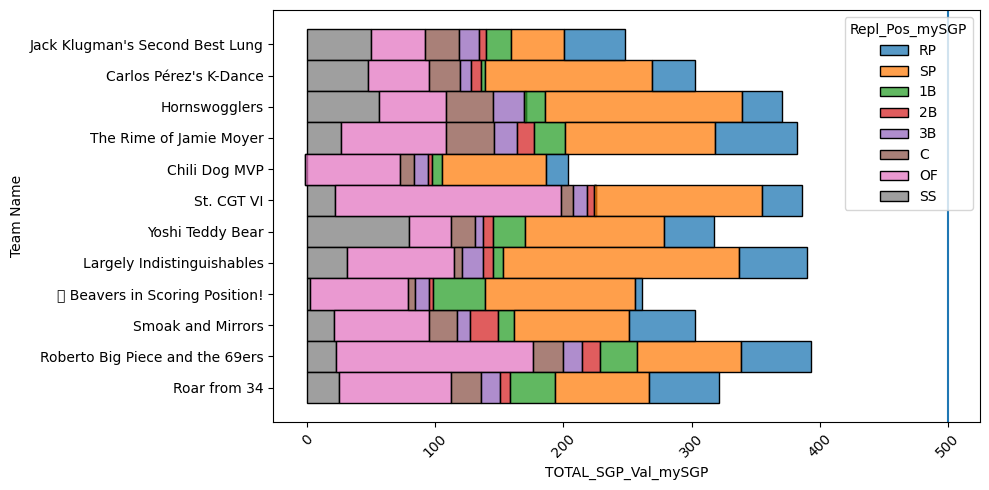

IP_mySGP_Team
Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV',
       'TOTAL_SGP_raw', 'R_SGP_Val_mySGP_Team', 'R_SGP_raw_mySGP_Team',
       'R_SGP_norm_mySGP_Team', 'mR_FGAV_Team', 'HR_SGP_Val_mySGP_Team',
       'HR_SGP_raw_mySGP_Team', 'HR_SGP_norm_mySGP_Team', 'mHR_FGAV_Team',
       'OBP_SGP_Val_mySGP_Team', 'OBP_SGP_raw_mySGP_Team',
       'OBP_SGP_norm_mySGP_Team', 'mOBP_FGAV_Team', 'SLG_SGP_Val_mySGP_Team',
       'SLG_SGP_raw_mySGP_Team', 'SLG_SGP_norm_mySGP_Team', 'mSLG_FGAV_Team',
       'SO_mySGP_Team', 'SO_SGP_Val_mySGP_Team', 'SO_SGP_raw_mySGP_Team',
       'SO_SGP_norm_mySGP_Team', 'mSO_FGAV_Team', 'HR9_Team',
       'HR9_SGP_Val_mySGP_Team', 'HR9_SGP_raw_mySGP_Team',
       'HR9_SGP_norm_mySGP_Team', 'ERA_Team', 'ERA_SGP_Val_mySGP_Team',
       'ERA_SGP_raw_mySGP_Team', 'ERA_SGP_norm_mySGP_Team', 'mERA_FGAV_Team',
       'WHIP_Team', 'WHIP_SGP_Val_mySGP_Team', 'WHIP_SGP_raw_

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


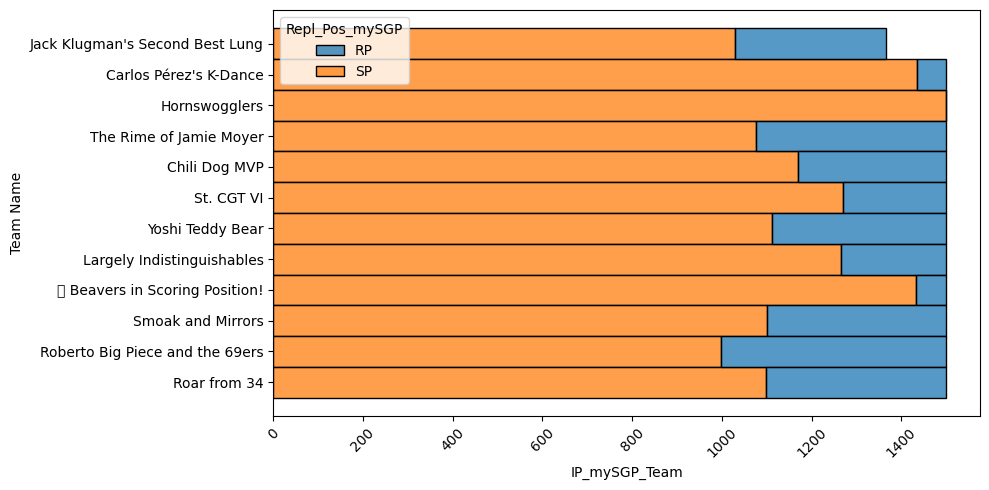

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


IP_FGAV_Team
Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV',
       'TOTAL_SGP_raw', 'R_SGP_Val_mySGP_Team', 'R_SGP_raw_mySGP_Team',
       'R_SGP_norm_mySGP_Team', 'mR_FGAV_Team', 'HR_SGP_Val_mySGP_Team',
       'HR_SGP_raw_mySGP_Team', 'HR_SGP_norm_mySGP_Team', 'mHR_FGAV_Team',
       'OBP_SGP_Val_mySGP_Team', 'OBP_SGP_raw_mySGP_Team',
       'OBP_SGP_norm_mySGP_Team', 'mOBP_FGAV_Team', 'SLG_SGP_Val_mySGP_Team',
       'SLG_SGP_raw_mySGP_Team', 'SLG_SGP_norm_mySGP_Team', 'mSLG_FGAV_Team',
       'SO_mySGP_Team', 'SO_SGP_Val_mySGP_Team', 'SO_SGP_raw_mySGP_Team',
       'SO_SGP_norm_mySGP_Team', 'mSO_FGAV_Team', 'HR9_Team',
       'HR9_SGP_Val_mySGP_Team', 'HR9_SGP_raw_mySGP_Team',
       'HR9_SGP_norm_mySGP_Team', 'ERA_Team', 'ERA_SGP_Val_mySGP_Team',
       'ERA_SGP_raw_mySGP_Team', 'ERA_SGP_norm_mySGP_Team', 'mERA_FGAV_Team',
       'WHIP_Team', 'WHIP_SGP_Val_mySGP_Team', 'WHIP_SGP_raw_m

/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


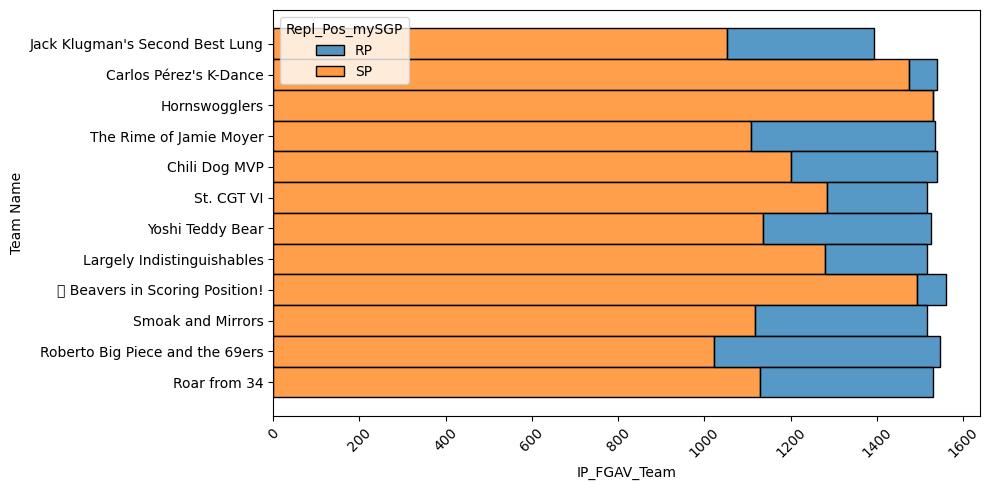

Salary


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


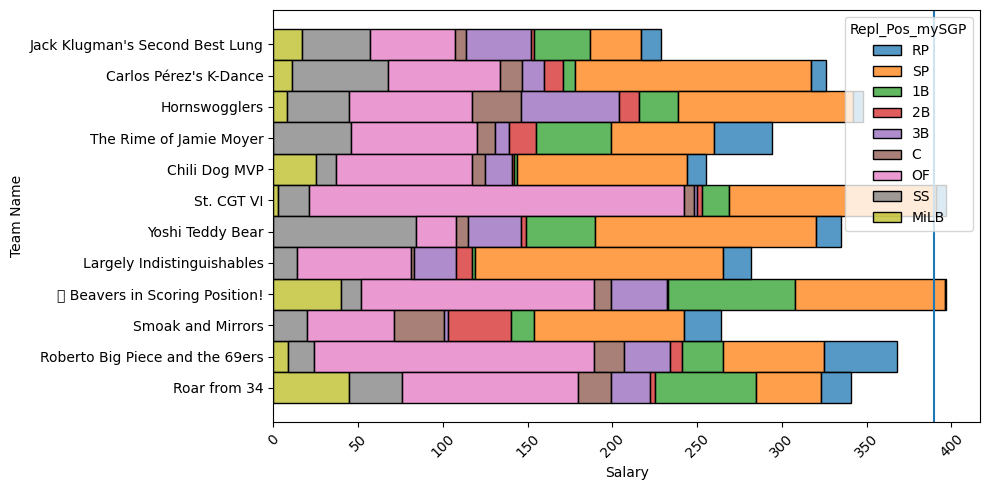

SP
SO
SO_mySGP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


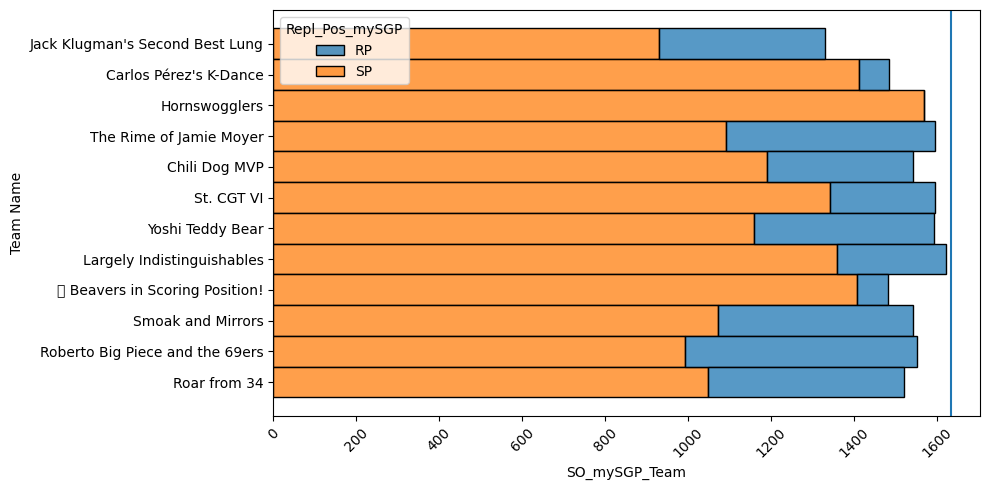

SO_SGP_Val_mySGP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


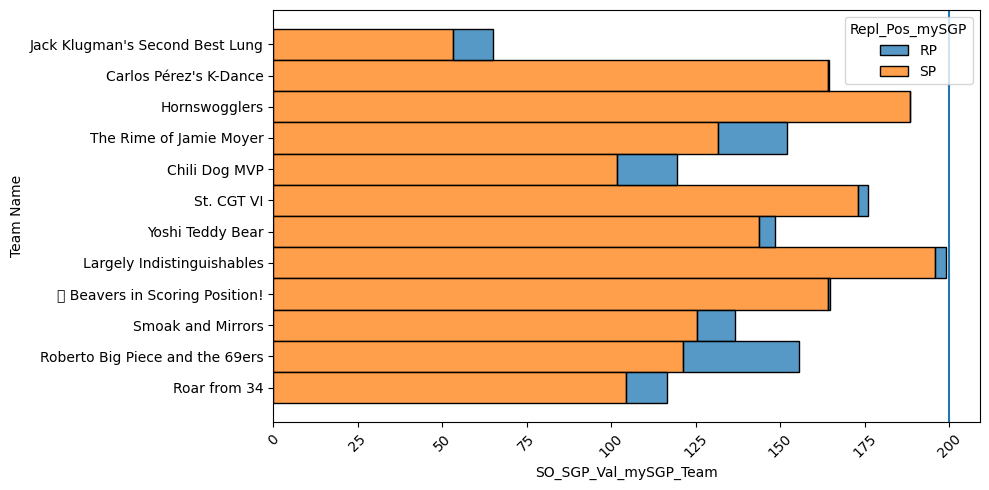

SP
HR9
HR9_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


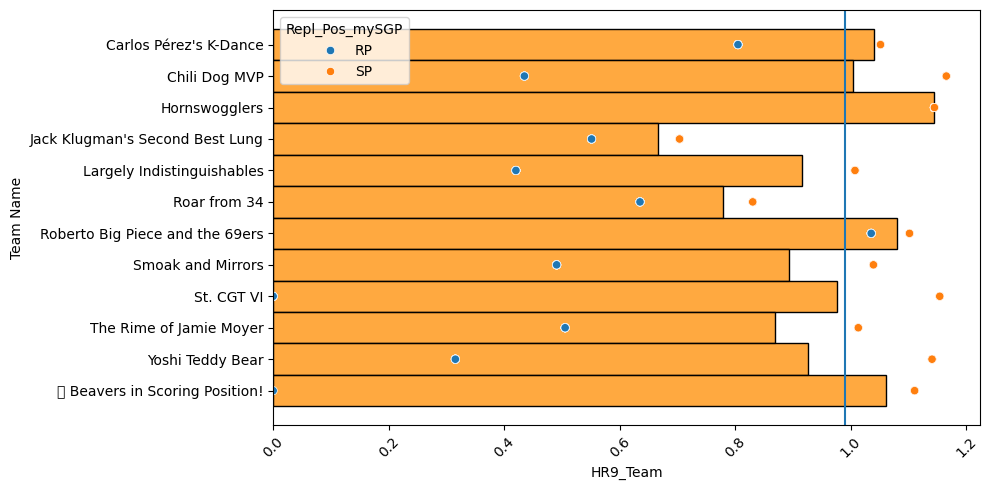

HR9_SGP_Val_mySGP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


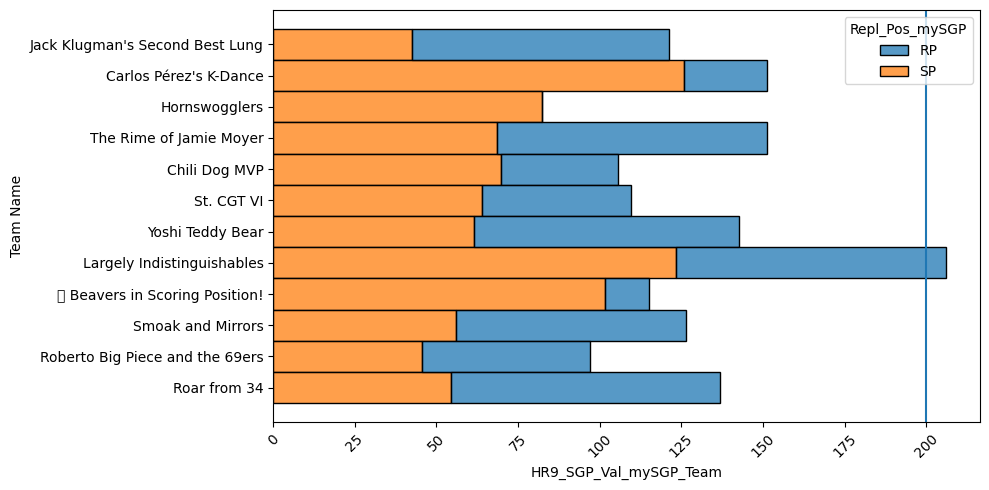

SP
ERA
ERA_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


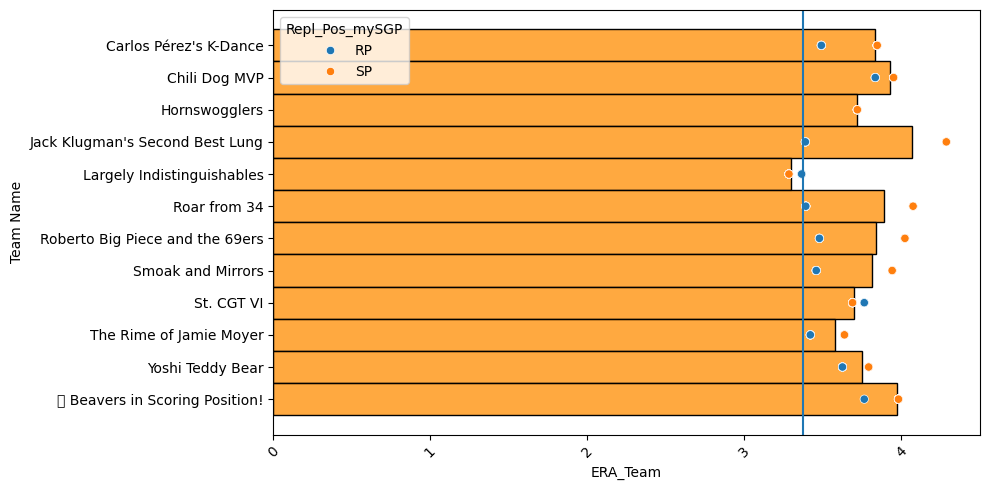

ERA_SGP_Val_mySGP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


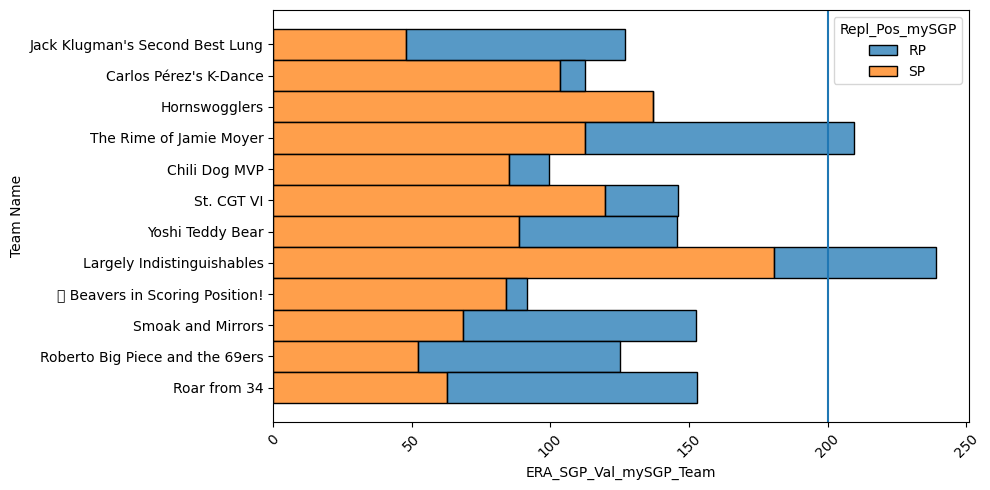

SP
WHIP
WHIP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


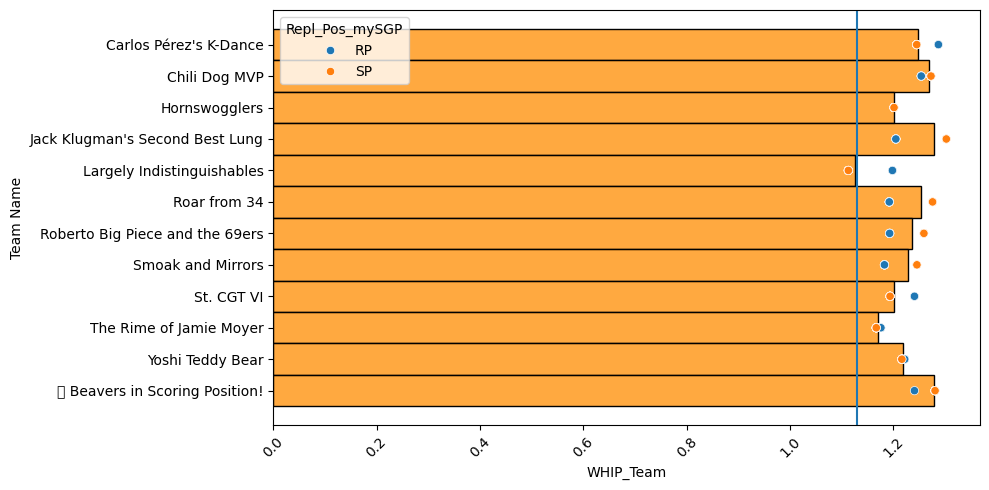

WHIP_SGP_Val_mySGP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


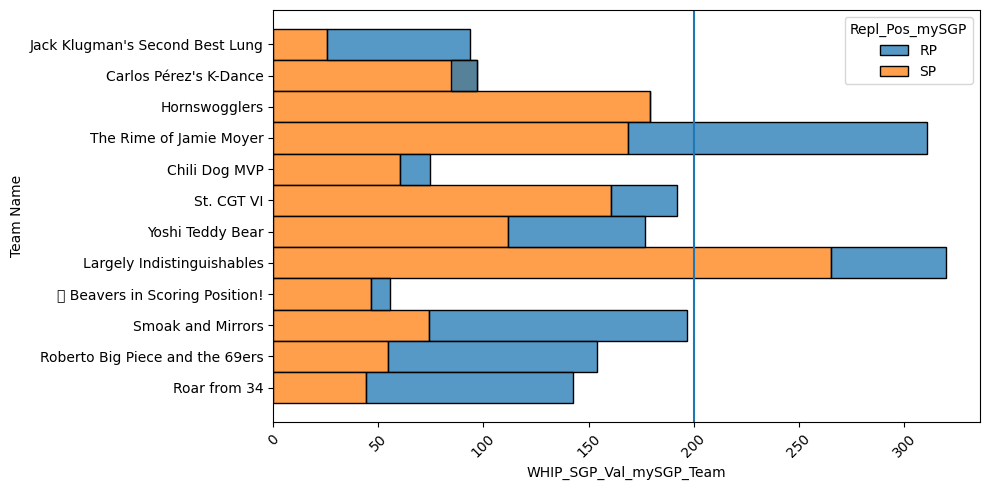

Util
G
TOTAL_SGP_Val_mySGP


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


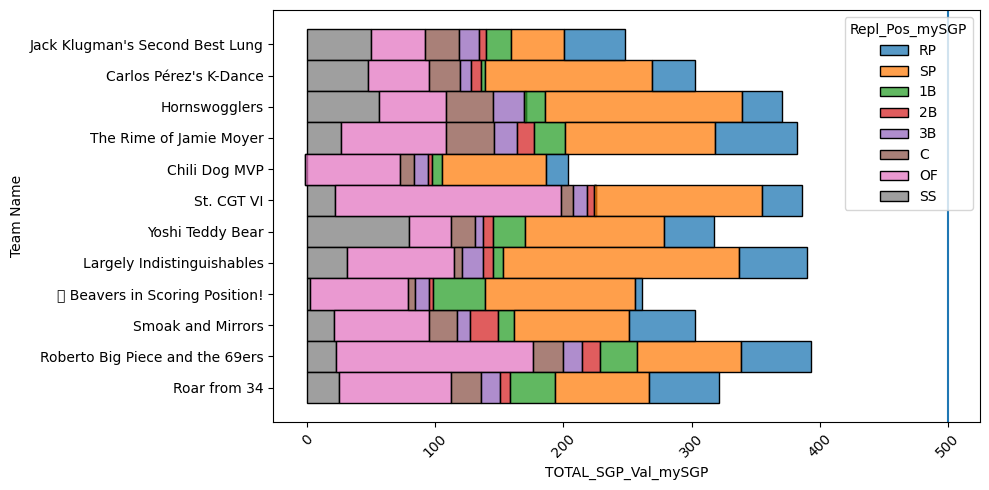

G_mySGP_Team
Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher',
       'TOTAL_SGP_raw', 'R_mySGP_Team', 'R_SGP_Val_mySGP_Team',
       'R_SGP_raw_mySGP_Team', 'R_SGP_norm_mySGP_Team', 'mR_FGAV_Team',
       'HR_mySGP_Team', 'HR_SGP_Val_mySGP_Team', 'HR_SGP_raw_mySGP_Team',
       'HR_SGP_norm_mySGP_Team', 'mHR_FGAV_Team', 'OBP_Team',
       'OBP_SGP_Val_mySGP_Team', 'OBP_SGP_raw_mySGP_Team',
       'OBP_SGP_norm_mySGP_Team', 'mOBP_FGAV_Team', 'SLG_Team',
       'SLG_SGP_Val_mySGP_Team', 'SLG_SGP_raw_mySGP_Team',
       'SLG_SGP_norm_mySGP_Team', 'mSLG_FGAV_Team', 'SO_SGP_Val_mySGP_Team',
       'SO_SGP_raw_mySGP_Team', 'SO_SGP_norm_mySGP_Team', 'mSO_FGAV_Team',
       'HR9_SGP_Val_mySGP_Team', 'HR9_SGP_raw_mySGP_Team',
       'HR9_SGP_norm_mySGP_Team', 'ERA_SGP_Val_mySGP_Team',
       'ERA_SGP_raw_mySGP_Team', 'ERA_SGP_norm_mySGP_Team', 'mERA_FGAV_Team',
       'WHIP_SGP_Val_mySGP_Team', 'WHIP_SGP_

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


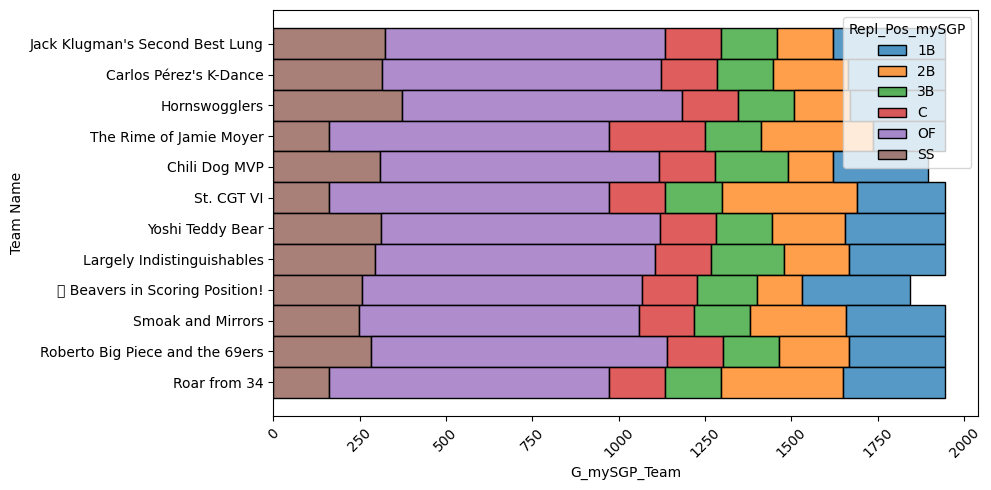

PA_mySGP_Team
Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher',
       'TOTAL_SGP_raw', 'R_mySGP_Team', 'R_SGP_Val_mySGP_Team',
       'R_SGP_raw_mySGP_Team', 'R_SGP_norm_mySGP_Team', 'mR_FGAV_Team',
       'HR_mySGP_Team', 'HR_SGP_Val_mySGP_Team', 'HR_SGP_raw_mySGP_Team',
       'HR_SGP_norm_mySGP_Team', 'mHR_FGAV_Team', 'OBP_Team',
       'OBP_SGP_Val_mySGP_Team', 'OBP_SGP_raw_mySGP_Team',
       'OBP_SGP_norm_mySGP_Team', 'mOBP_FGAV_Team', 'SLG_Team',
       'SLG_SGP_Val_mySGP_Team', 'SLG_SGP_raw_mySGP_Team',
       'SLG_SGP_norm_mySGP_Team', 'mSLG_FGAV_Team', 'SO_SGP_Val_mySGP_Team',
       'SO_SGP_raw_mySGP_Team', 'SO_SGP_norm_mySGP_Team', 'mSO_FGAV_Team',
       'HR9_SGP_Val_mySGP_Team', 'HR9_SGP_raw_mySGP_Team',
       'HR9_SGP_norm_mySGP_Team', 'ERA_SGP_Val_mySGP_Team',
       'ERA_SGP_raw_mySGP_Team', 'ERA_SGP_norm_mySGP_Team', 'mERA_FGAV_Team',
       'WHIP_SGP_Val_mySGP_Team', 'WHIP_SGP

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


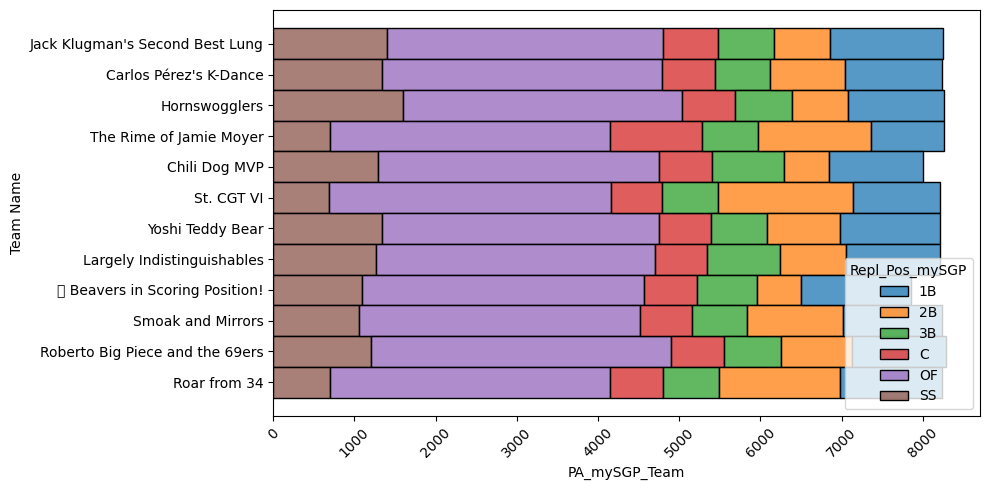

PA_FGAV_Team
Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher',
       'TOTAL_SGP_raw', 'R_mySGP_Team', 'R_SGP_Val_mySGP_Team',
       'R_SGP_raw_mySGP_Team', 'R_SGP_norm_mySGP_Team', 'mR_FGAV_Team',
       'HR_mySGP_Team', 'HR_SGP_Val_mySGP_Team', 'HR_SGP_raw_mySGP_Team',
       'HR_SGP_norm_mySGP_Team', 'mHR_FGAV_Team', 'OBP_Team',
       'OBP_SGP_Val_mySGP_Team', 'OBP_SGP_raw_mySGP_Team',
       'OBP_SGP_norm_mySGP_Team', 'mOBP_FGAV_Team', 'SLG_Team',
       'SLG_SGP_Val_mySGP_Team', 'SLG_SGP_raw_mySGP_Team',
       'SLG_SGP_norm_mySGP_Team', 'mSLG_FGAV_Team', 'SO_SGP_Val_mySGP_Team',
       'SO_SGP_raw_mySGP_Team', 'SO_SGP_norm_mySGP_Team', 'mSO_FGAV_Team',
       'HR9_SGP_Val_mySGP_Team', 'HR9_SGP_raw_mySGP_Team',
       'HR9_SGP_norm_mySGP_Team', 'ERA_SGP_Val_mySGP_Team',
       'ERA_SGP_raw_mySGP_Team', 'ERA_SGP_norm_mySGP_Team', 'mERA_FGAV_Team',
       'WHIP_SGP_Val_mySGP_Team', 'WHIP_SGP_

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


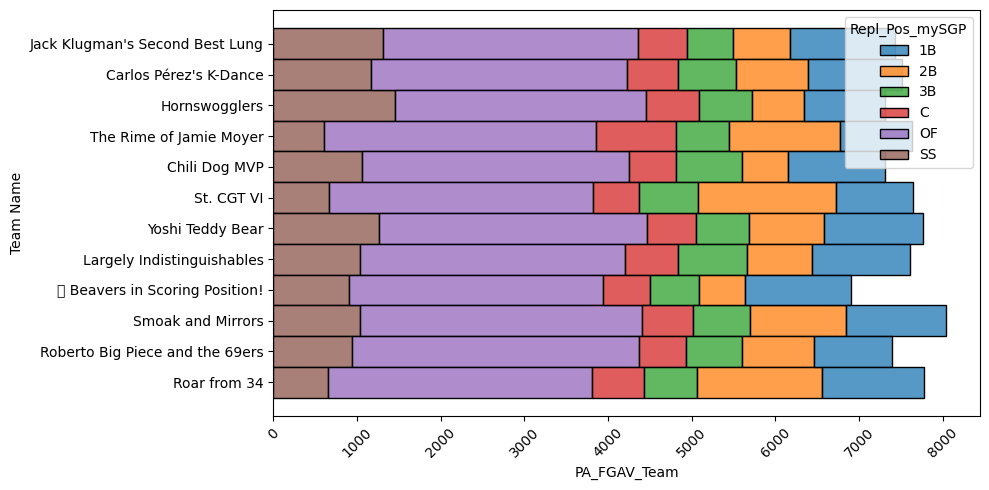

Salary


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


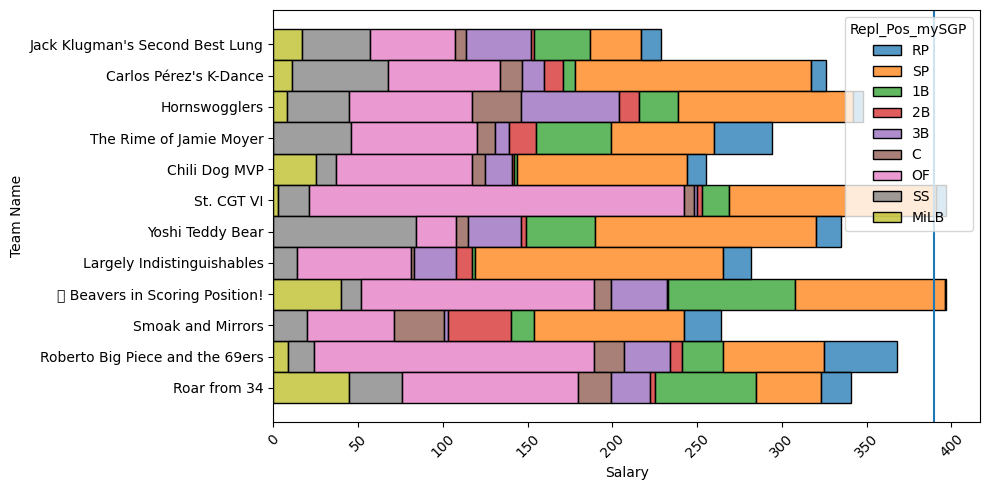

Util
R
R_mySGP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


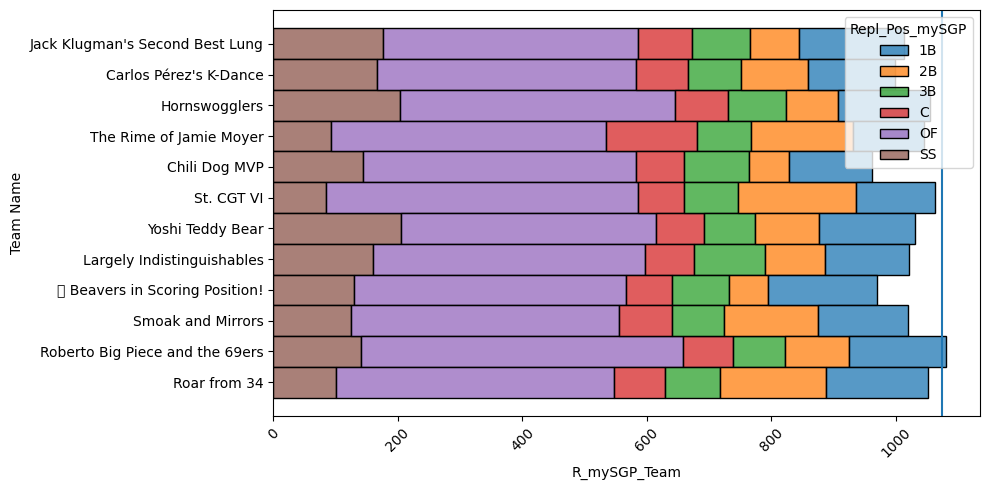

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


R_SGP_Val_mySGP_Team


/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


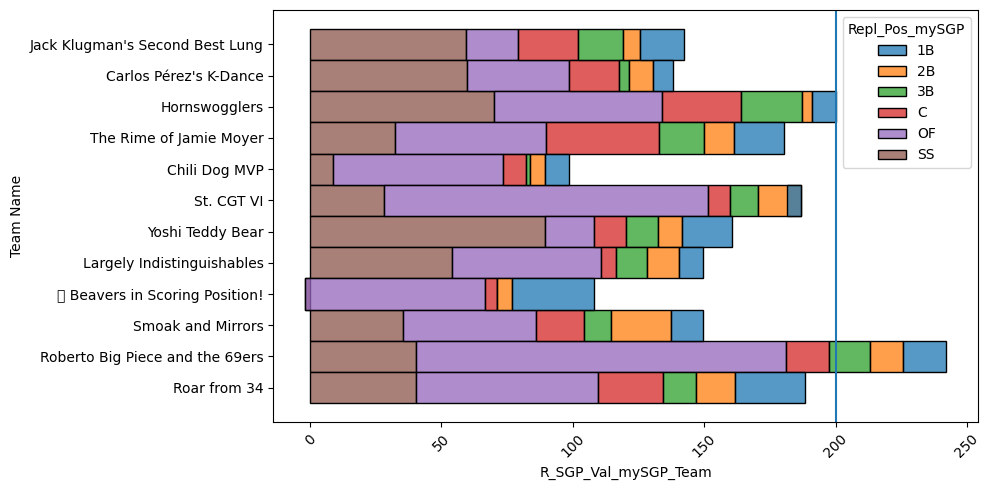

Util
HR
HR_mySGP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


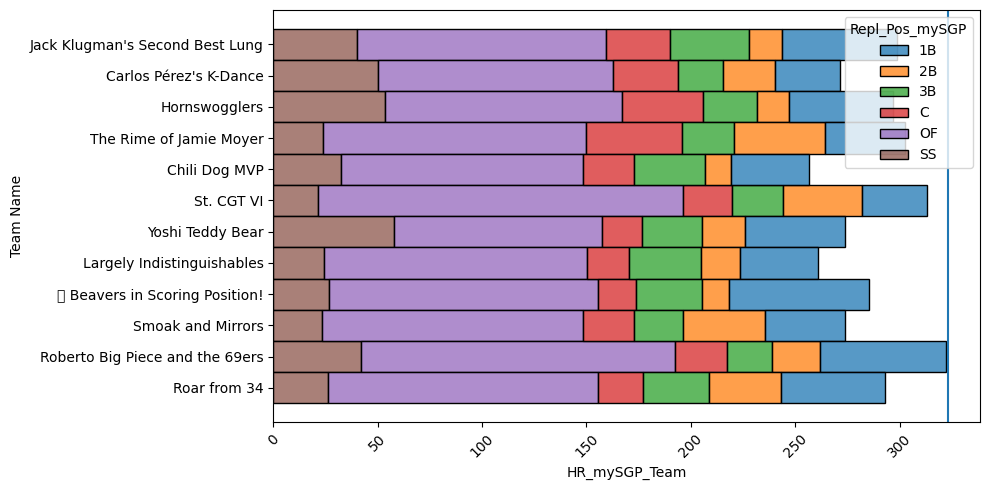

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


HR_SGP_Val_mySGP_Team


/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


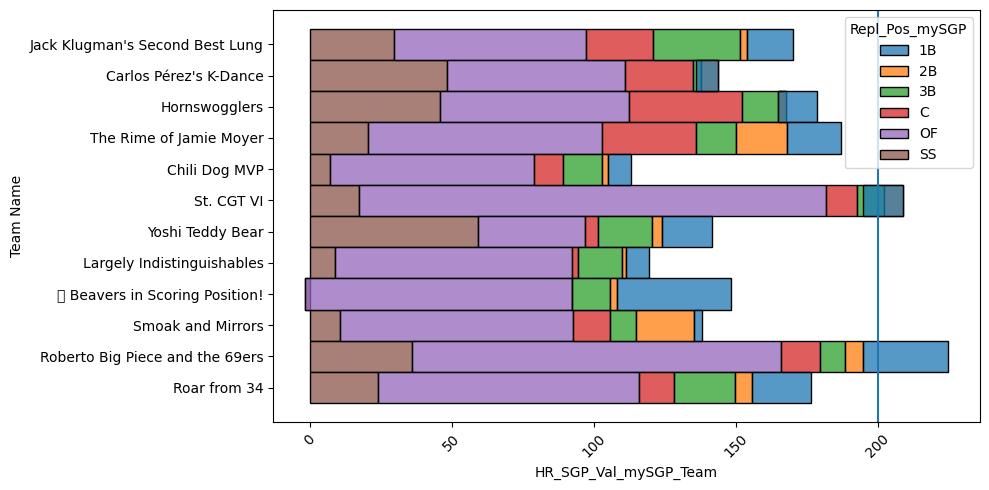

Util
OBP
OBP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


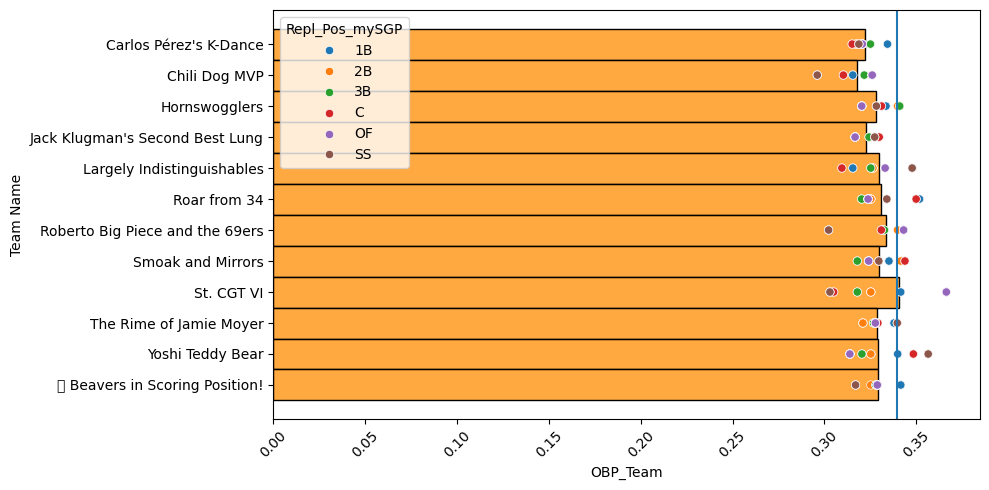

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


OBP_SGP_Val_mySGP_Team


/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


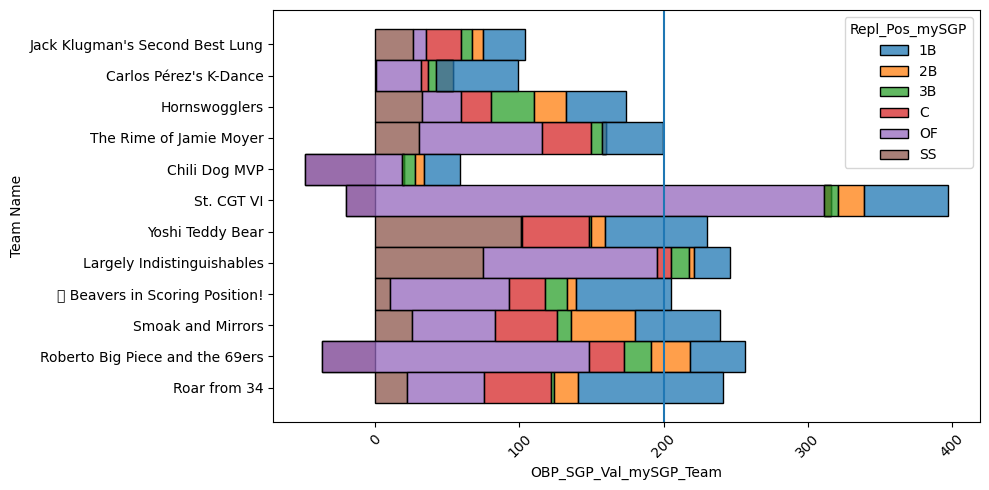

Util
SLG
SLG_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


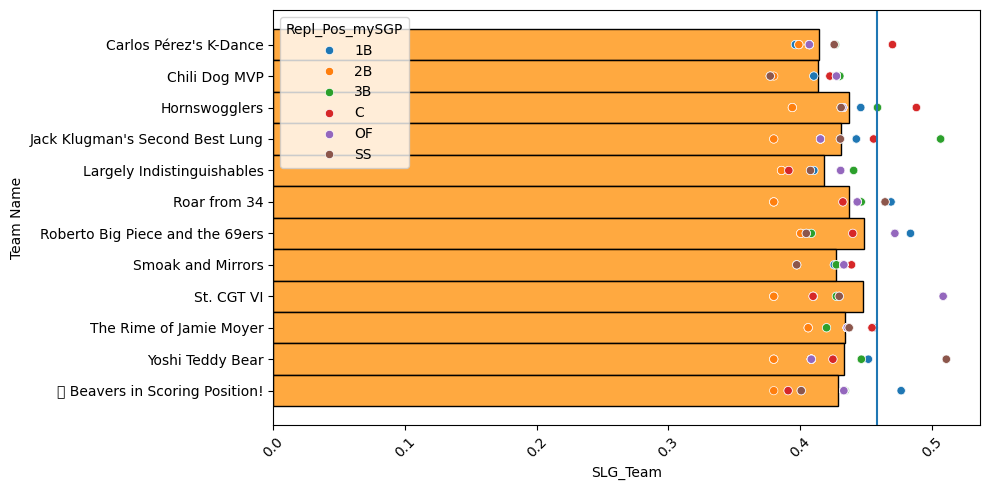

SLG_SGP_Val_mySGP_Team


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_44543/1774167488.py:34: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129451 (\N{BEAVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


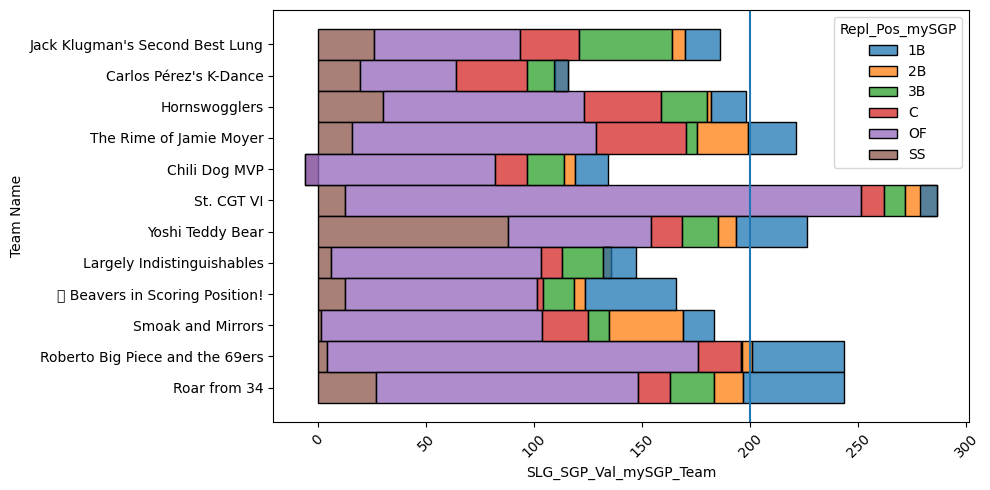

In [122]:
for pos in ['SP','Util']:
    This_Pos_Stat_Cats = Pitching_value_columns if pos in Pitching_Pos else Batting_value_columns
    for stat_cat, stat_cols in This_Pos_Stat_Cats.items():
        # if Stat in bugged_cols:
        #     continue
        print(pos)
        print(stat_cat)
        # print(All_teams_replacement_level[stat_cat])
        # fig1 = plt.figure(figsize=(10,5))
        # ax1 = fig1.add_subplot(111)
        # sns.histplot(All_teams_replacement_level,x='Team Name',weights=stat_cat,hue='Ottoneu Positions', multiple='stack',ax=ax1)
        # ax1.axhline(y=Target_Stats_df[stat_cat])
        # plt.tight_layout()
        # plt.show()
        
        

        for stat in stat_cols:
            print(stat)
            fig2 = plt.figure(figsize=(10,5))
            ax2 = fig2.add_subplot(111)
            if stat in Team_Rate_Cols:
                sns.histplot(All_teams_replacement_level[All_teams_replacement_level['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_teams_replacement_level)].dropna(subset=stat).groupby('Team Name')[stat].mean().reset_index(),y='Team Name',weights=stat,color='darkorange',ax=ax2)
                sns.scatterplot(All_teams_replacement_level[All_teams_replacement_level['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_teams_replacement_level)].dropna(subset=stat.replace('_','_pos_')),y='Team Name',x=stat.replace('_','_pos_'),hue='Repl_Pos_mySGP',ax=ax2)
            else:
                sns.histplot(All_teams_replacement_level[All_teams_replacement_level['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_teams_replacement_level)].dropna(subset=stat),y='Team Name',weights=stat,hue='Repl_Pos_mySGP', multiple='stack',ax=ax2)
            ax2.tick_params(axis='x', labelrotation=45)
            ax2.set_xlabel(stat)
            ax2.set_ylabel('Team Name')
            if (stat in Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')].dropna(axis=1).columns):
                ax2.axvline(x=Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0],label='Target')
            else:
                print(Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')].dropna(axis=1).columns)
            plt.tight_layout()
            plt.show()
            #sns.histplot(All_teams_replacement_level.dropna(subset=stat),y=stat,hue=)

In [123]:
All_teams_replacement_level

,TeamID,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,...,OBP_SGP_Val_mySGP_Team,SLG_SGP_Val_mySGP_Team,PA_FGAV_Team,mR_FGAV_Team,mOBP_FGAV_Team,mSLG_FGAV_Team,OBP_Team,OBP_pos_Team,SLG_Team,SLG_pos_Team
0,55.0,25327,MIL,70.22,NaN,NaN,52.43,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55.0,10233,BOS,61.24,NaN,NaN,43.45,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,55.0,19427,TOR,23.49,NaN,NaN,133.80,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,55.0,33927,CHW,69.85,NaN,NaN,61.85,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,55.0,23796,NYY,37.90,NaN,NaN,115.38,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,185.0,sa3018409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
453,185.0,sa3020498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
454,185.0,sa3020949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
455,185.0,sa3024108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [124]:
All_Teams_csv_path = League_path+'/Rosters'+f'/Kept_Players_and_Replacement_Level_{Calc_date}.csv'

In [125]:
All_teams_replacement_level.to_csv(All_Teams_csv_path,index=False)